In [1]:
# IMPORT LIBRARIES
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# functions.py, plotly and matplotlib.image are carried over from the local version of
# this notebook but are not referenced by any cell here. They are imported defensively so
# a Colab runtime holding only the CSV exports still runs.
try:
    import plotly.express as px
    import matplotlib.image as mpimg
    import functions
except ImportError as exc:
    print(f'Optional import unavailable (not used by this notebook): {exc.name}')

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Figures are written to images/days throughout the notebook. On a fresh Colab
# runtime that directory does not exist, which previously aborted every savefig call.
IMAGE_DIR = 'images/days'
os.makedirs(IMAGE_DIR, exist_ok=True)


Optional import unavailable (not used by this notebook): functions


# EV Charging Station Data Analysis

This notebook analyzes electric vehicle (EV) charging station data from Santa Barbara County to identify patterns, trends, and forecast future energy needs. The analysis will help inform capacity planning decisions for charging infrastructure expansion.

**Data coverage:** 2020-01-01 through 2026-07-30 (2,403 consecutive days), assembled from four provider exports. The 2020-2024 portion reports the 16 *County Public* sites; the 2025-2026 portion reports all 22 *All Sites* locations. That scope change is measured and accounted for in the "Reporting Scope Change" section below, and it matters for how the trend should be read.

## Objectives:
1. Prepare and clean the charging station dataset
2. Perform exploratory and statistical analysis to understand patterns
3. Build time series models to forecast future energy delivery needs
4. Generate actionable insights for infrastructure planning

> **Running this notebook on Colab:** the loader reads from the `DATA_DIR` folder
> (`data` by default). Upload the four daily reporting exports listed in the import cell
> — plus `functions.py` — into the runtime before running, or point `DATA_DIR` at a
> mounted Drive folder. The two session-level exports are optional; without them the
> scope analysis falls back to a pre-computed constant.

## Colab Setup: Load the Data from Google Drive

Run this cell **before** the import cell below when working in Colab. It points `DATA_DIR`
at the shared Drive folder, trying two strategies in order:

1. **Mount and search** — mounts your Drive and looks for the folder that contains the
   reporting exports. This is the fast path and needs no extra permissions.
2. **Download by folder ID** — if the folder is under *Shared with me* rather than *My
   Drive* (where mounting will not expose it), the files are fetched through the Drive
   API into `/content/data` instead.

Skip this cell entirely when running locally; `DATA_DIR` then defaults to `data`.

In [2]:
# ============================================================================
# COLAB DATA SETUP - point DATA_DIR at the reporting exports on Google Drive
# Source folder:
# https://drive.google.com/drive/folders/16yPYaqURnHmhIHARRP8anrnMUwgfxuFF
# Safe to run anywhere: off Colab it just selects the local data folder.
# ============================================================================
import os

DRIVE_FOLDER_ID = '16yPYaqURnHmhIHARRP8anrnMUwgfxuFF'
LOCAL_DATA_DIR = 'data'

# The four daily exports the analysis cannot run without.
REQUIRED_FILES = [
    'SB-County-County Public reporting 2020-01-01_2024-12-31.csv',
    'SB County-All Sites reporting 2025-01-01_2025-05-31.csv',
    'SB County-All Sites reporting 2025-06-01_2025-12-31.csv',
    'SB County-All Sites reporting 2026-01-01_2026-07-30.csv',
]
# Session-level exports. Only used to measure the 2025 reporting scope change; without
# them that section falls back to a pre-computed constant.
OPTIONAL_FILES = [
    'SB-County-County-Public-Portfolio-stations-report-01_01_20-12_31_24.csv',
    'SB_County-All_Sites-portfolio_sessions_report-01_01_26-07_31_26.csv',
]


def _folder_is_complete(path):
    """True when every required export is present in path."""
    return bool(path) and all(os.path.exists(os.path.join(path, f)) for f in REQUIRED_FILES)


try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

DATA_DIR = None

if not IN_COLAB:
    DATA_DIR = LOCAL_DATA_DIR
    print(f'Not running on Colab - using the local folder {DATA_DIR!r}.')
else:
    # --- Strategy 1: mount Drive and locate the folder by its contents -------
    from google.colab import drive

    drive.mount('/content/drive')

    marker = REQUIRED_FILES[0]
    # Search My Drive first, then the wider mount point, skipping hidden directories.
    for search_root in ('/content/drive/MyDrive', '/content/drive'):
        if not os.path.isdir(search_root):
            continue
        for root, dirs, files in os.walk(search_root):
            dirs[:] = [d for d in dirs if not d.startswith('.')]
            if marker in files:
                DATA_DIR = root
                break
        if DATA_DIR:
            break

    if DATA_DIR:
        print(f'Found the data on Drive: {DATA_DIR}')
    else:
        print('Folder not visible under the mount (likely "Shared with me").')
        print('Falling back to a direct download by folder ID...')

    # --- Strategy 2: download by folder ID (covers "Shared with me") ---------
    if not _folder_is_complete(DATA_DIR):
        from google.colab import auth
        from googleapiclient.discovery import build
        from googleapiclient.http import MediaIoBaseDownload

        auth.authenticate_user()
        service = build('drive', 'v3')

        DATA_DIR = '/content/data'
        os.makedirs(DATA_DIR, exist_ok=True)
        wanted = set(REQUIRED_FILES + OPTIONAL_FILES)

        page_token = None
        while True:
            response = service.files().list(
                q=f"'{DRIVE_FOLDER_ID}' in parents and trashed = false",
                fields='nextPageToken, files(id, name)',
                pageToken=page_token,
                supportsAllDrives=True,
                includeItemsFromAllDrives=True,
            ).execute()

            for item in response.get('files', []):
                if item['name'] not in wanted:
                    continue
                destination = os.path.join(DATA_DIR, item['name'])
                if os.path.exists(destination):
                    continue
                with open(destination, 'wb') as handle:
                    downloader = MediaIoBaseDownload(
                        handle, service.files().get_media(fileId=item['id'])
                    )
                    done = False
                    while not done:
                        _, done = downloader.next_chunk()
                print(f'  downloaded {item["name"]}')

            page_token = response.get('nextPageToken')
            if not page_token:
                break

# --- Verify ------------------------------------------------------------------
print(f'\nDATA_DIR = {DATA_DIR!r}')
for filename in REQUIRED_FILES:
    ok = os.path.exists(os.path.join(DATA_DIR or '', filename))
    print(f'  [{"ok" if ok else "MISSING"}] {filename}')
for filename in OPTIONAL_FILES:
    ok = os.path.exists(os.path.join(DATA_DIR or '', filename))
    print(f'  [{"ok" if ok else "absent (optional)"}] {filename}')

missing = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(DATA_DIR or '', f))]
if missing:
    raise FileNotFoundError(
        f'{len(missing)} required export(s) not found in {DATA_DIR!r}. '
        'Confirm the Drive folder is shared with the account you authenticated as, '
        'or set DATA_DIR manually.'
    )
print('\nAll required exports available - run the import cell next.')


Mounted at /content/drive
Found the data on Drive: /content/drive/MyDrive/AIML/Capstone/PowerFlexData-2020-2026/data

DATA_DIR = '/content/drive/MyDrive/AIML/Capstone/PowerFlexData-2020-2026/data'
  [ok] SB-County-County Public reporting 2020-01-01_2024-12-31.csv
  [ok] SB County-All Sites reporting 2025-01-01_2025-05-31.csv
  [ok] SB County-All Sites reporting 2025-06-01_2025-12-31.csv
  [ok] SB County-All Sites reporting 2026-01-01_2026-07-30.csv
  [ok] SB-County-County-Public-Portfolio-stations-report-01_01_20-12_31_24.csv
  [ok] SB_County-All_Sites-portfolio_sessions_report-01_01_26-07_31_26.csv

All required exports available - run the import cell next.


In [3]:
# IMPORT REPORTING DATA
# The daily reporting series is assembled from four provider exports that span two
# different report scopes:
#   2020-01-01 -> 2024-12-31   "County Public"  (16 sites)
#   2025-01-01 -> 2026-07-30   "All Sites"      (22 sites: the same 16 plus 6 more)
# The scope change is recorded per row so its effect can be measured downstream.

# Set by the Colab setup cell when the data lives on Google Drive; falls back to the
# local repository layout when that cell has not been run.
DATA_DIR = globals().get('DATA_DIR') or 'data'

REPORTING_FILES = [
    ('SB-County-County Public reporting 2020-01-01_2024-12-31.csv', 'County Public'),
    ('SB County-All Sites reporting 2025-01-01_2025-05-31.csv',     'All Sites'),
    ('SB County-All Sites reporting 2025-06-01_2025-12-31.csv',     'All Sites'),
    ('SB County-All Sites reporting 2026-01-01_2026-07-30.csv',     'All Sites'),
]


def load_reporting_file(filename, scope):
    """Read one daily reporting export and normalise it onto a plain daily date."""
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    # The first header carries a UTF-8 BOM and some headers have stray whitespace.
    df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]
    # 2020-2024 exports write "2024-12-31"; 2025+ exports write
    # "2025-01-01 12:00 am PST". Strip the constant midnight-and-timezone suffix
    # so both parse to the same plain daily timestamp.
    day = df['Day'].astype(str).str.replace(r'\s+12:00\s+am\s+P[SD]T$', '', regex=True)
    df['Day'] = pd.to_datetime(day)
    df['Reporting Scope'] = scope
    df['Source File'] = filename
    return df


df_reporting = (
    pd.concat([load_reporting_file(f, s) for f, s in REPORTING_FILES], ignore_index=True)
      .sort_values('Day')
      .reset_index(drop=True)
)

# Integrity checks: the concatenated series must be a gap-free, duplicate-free daily index.
expected_days = pd.date_range(df_reporting['Day'].min(), df_reporting['Day'].max(), freq='D')
duplicate_days = int(df_reporting['Day'].duplicated().sum())
missing_days = len(set(expected_days) - set(df_reporting['Day']))

print('Loaded daily reporting data')
for filename, scope in REPORTING_FILES:
    grp = df_reporting[df_reporting['Source File'] == filename]
    print(f"  {scope:<14s} {grp['Day'].min():%Y-%m-%d} -> {grp['Day'].max():%Y-%m-%d}  ({len(grp):>4d} days)  {filename}")
print(f"\nCombined range : {df_reporting['Day'].min():%Y-%m-%d} -> {df_reporting['Day'].max():%Y-%m-%d}")
print(f"Total days     : {len(df_reporting)}")
print(f"Duplicate days : {duplicate_days}")
print(f"Missing days   : {missing_days}")
assert duplicate_days == 0 and missing_days == 0, 'Daily index is not contiguous'


Loaded daily reporting data
  County Public  2020-01-01 -> 2024-12-31  (1827 days)  SB-County-County Public reporting 2020-01-01_2024-12-31.csv
  All Sites      2025-01-01 -> 2025-05-31  ( 151 days)  SB County-All Sites reporting 2025-01-01_2025-05-31.csv
  All Sites      2025-06-01 -> 2025-12-31  ( 214 days)  SB County-All Sites reporting 2025-06-01_2025-12-31.csv
  All Sites      2026-01-01 -> 2026-07-30  ( 211 days)  SB County-All Sites reporting 2026-01-01_2026-07-30.csv

Combined range : 2020-01-01 -> 2026-07-30
Total days     : 2403
Duplicate days : 0
Missing days   : 0


In [4]:
df_reporting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2403 entries, 0 to 2402
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Day                                  2403 non-null   datetime64[ns]
 1   Started Sessions                     2403 non-null   int64         
 2   Completed Sessions                   2403 non-null   int64         
 3   Microsessions                        2403 non-null   int64         
 4   AVG session duration (minutes)       2400 non-null   float64       
 5   AVG charging duration (minutes)      2403 non-null   float64       
 6   AVG session idle (minutes)           2400 non-null   float64       
 7   Energy delivered (kWh)               2403 non-null   float64       
 8   AVG kWh delivered per session (kWh)  2403 non-null   float64       
 9   Max kWh delivered per session (kWh)  2403 non-null   float64       
 10  Max kW hour 

## Reporting Scope Change (2025-01-01)

The four source exports do not all describe the same set of chargers:

| Period | Export scope | Sites |
|---|---|---|
| 2020-01-01 - 2024-12-31 | County Public | 16 |
| 2025-01-01 - 2026-07-30 | All Sites | 22 |

The 16 County Public sites are a strict **subset** of the 22 All Sites locations, so no
site disappears from the series; six are added on 2025-01-01. Cross-checking the
session-level exports, the six added sites are `SM Garage`, `SB South County Jail`,
`CSB Santa Maria Jail`, `CSB Sta 27 New Cuyama`, `RFCC` and `RFCC (com)`.

This produces a **one-off upward level shift** at the 2025 boundary that is a reporting
artefact rather than demand growth. The cell below measures both the size of the artefact
and the size of the observed jump, so the two can be told apart.

Note that the two do not fully explain each other: the added sites account for roughly
10.6% of delivered energy, while the observed month-over-month jump is considerably
larger. The remainder is genuine, and it is followed by a sustained decline through the
rest of 2025 that happens *within* a single consistent scope.

In [5]:
# QUANTIFY THE REPORTING SCOPE CHANGE
SCOPE_CHANGE_DATE = '2025-01-01'

# Share of All-Sites energy that comes from the original 16 County Public sites.
# Derived from the session-level exports when they are available, otherwise the
# pre-computed value is used so the notebook still runs on a bare Colab upload.
SCOPE_LEGACY_SHARE = 0.8941  # fallback, measured from the 2026 session-level export

_legacy_sessions = os.path.join(DATA_DIR, 'SB-County-County-Public-Portfolio-stations-report-01_01_20-12_31_24.csv')
_allsites_sessions = os.path.join(DATA_DIR, 'SB_County-All_Sites-portfolio_sessions_report-01_01_26-07_31_26.csv')

if os.path.exists(_legacy_sessions) and os.path.exists(_allsites_sessions):
    def _read_sessions(path):
        d = pd.read_csv(path, low_memory=False)
        d.columns = [c.strip().strip('"').lstrip('\ufeff') for c in d.columns]
        return d

    _legacy_sites = set(_read_sessions(_legacy_sessions)['Site'].dropna().unique())
    _all = _read_sessions(_allsites_sessions)
    _all['kWh delivered'] = pd.to_numeric(_all['kWh delivered'], errors='coerce')
    _is_legacy = _all['Site'].isin(_legacy_sites)

    _total_kwh = _all['kWh delivered'].sum()
    _legacy_kwh = _all.loc[_is_legacy, 'kWh delivered'].sum()
    SCOPE_LEGACY_SHARE = _legacy_kwh / _total_kwh

    _added = sorted(set(_all['Site'].dropna().unique()) - _legacy_sites)
    print(f'Sites in County Public export : {len(_legacy_sites)}')
    print(f'Sites in All Sites export     : {_all["Site"].nunique()}')
    print(f'Sites added on {SCOPE_CHANGE_DATE}     : {len(_added)} -> {", ".join(_added)}')
    print(f'\nEnergy from the 6 added sites : {100 * (1 - SCOPE_LEGACY_SHARE):.2f}% of all-sites total')
else:
    print('Session-level exports not found; using pre-computed scope share.')

print(f'SCOPE_LEGACY_SHARE = {SCOPE_LEGACY_SHARE:.4f}  '
      f'(uplift to convert County Public -> All Sites: {1 / SCOPE_LEGACY_SHARE:.4f})')

# Compare the artefact against the level shift actually observed in the daily series.
_energy = df_reporting.set_index('Day')['Energy delivered (kWh)']
_before = _energy[:pd.Timestamp(SCOPE_CHANGE_DATE) - pd.Timedelta(days=1)].last('90D').mean()
_after = _energy[SCOPE_CHANGE_DATE:].first('90D').mean()

print(f'\nMean daily energy, 90 days before {SCOPE_CHANGE_DATE}: {_before:8.1f} kWh')
print(f'Mean daily energy, 90 days after  {SCOPE_CHANGE_DATE}: {_after:8.1f} kWh')
print(f'Observed level shift : {100 * (_after / _before - 1):+.1f}%')
print(f'Explained by scope   : {100 * (1 / SCOPE_LEGACY_SHARE - 1):+.1f}%')
print(f'Unexplained residual : {100 * ((_after / _before) * SCOPE_LEGACY_SHARE - 1):+.1f}%')


Sites in County Public export : 16
Sites in All Sites export     : 22
Sites added on 2025-01-01     : 6 -> CSB Santa Maria Jail, CSB Sta 27 New Cuyama, RFCC, RFCC (com), SB South County Jail, SM Garage

Energy from the 6 added sites : 10.59% of all-sites total
SCOPE_LEGACY_SHARE = 0.8941  (uplift to convert County Public -> All Sites: 1.1184)

Mean daily energy, 90 days before 2025-01-01:   1354.1 kWh
Mean daily energy, 90 days after  2025-01-01:   1939.3 kWh
Observed level shift : +43.2%
Explained by scope   : +11.8%
Unexplained residual : +28.0%


## Data Preparation

### Santa Barbara County Reporting Data

In [6]:
print(f"The dataframe has {df_reporting.shape[0]} and {df_reporting.shape[1]} columns")

The dataframe has 2403 and 24 columns


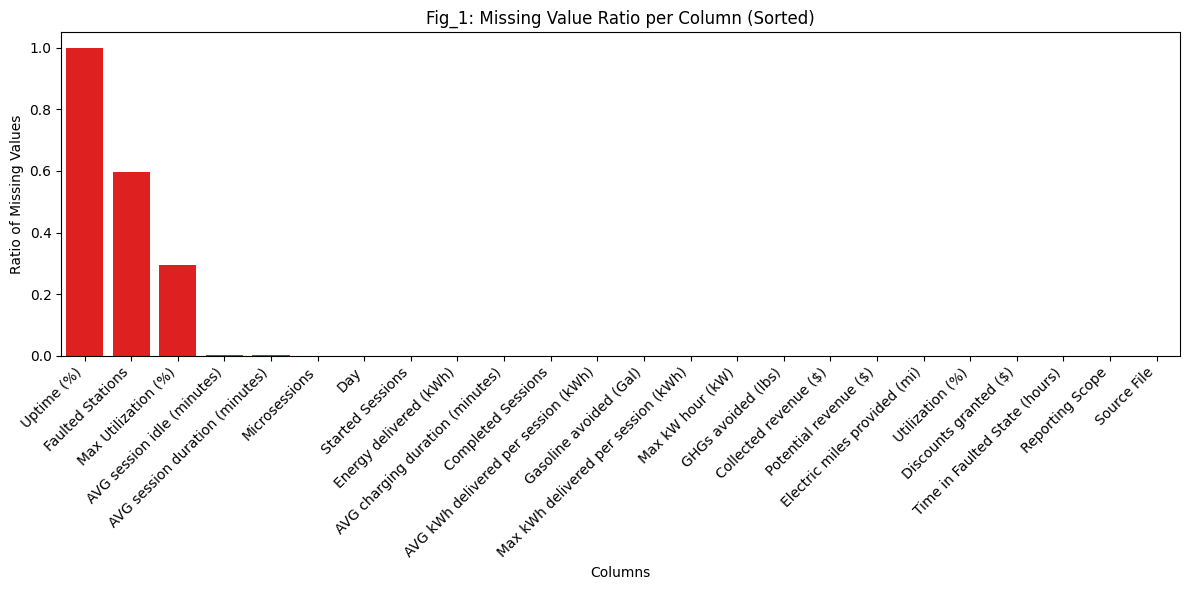

In [7]:
# Gets the mean of missing values in each column. Since True = 1 and False = 0 the mean tells us how much of the data is missing.
# Sinde the value "-" was we are first replacing it for np.nan and then checking for the missing values.
df_reporting_w_missing_values = df_reporting.replace("-", np.nan).isnull().mean().sort_values(ascending=False)

# Create the bar plot with Seaborn
plt.figure(figsize=(12, 6))
fig1 = sns.barplot(x=df_reporting_w_missing_values.index, y=df_reporting_w_missing_values.values, color='red')

# Customize the plot
plt.xlabel('Columns')
plt.ylabel('Ratio of Missing Values')
plt.title('Fig_1: Missing Value Ratio per Column (Sorted)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the plot
# plt.savefig('images/days/fig1.jpg')

# Show the plot
plt.show()

### Missing Value Analysis

The bar plot above shows the proportion of missing values in each column. Several observations:

- Some features have significant amounts of missing data, particularly `Max kW hour (kW)`, `Max Utilization (%)`, `Faulted Stations`, and `Uptime (%)`
- These missing values aren't random - they reflect changes in data collection methods over time as the EV charging infrastructure monitoring evolved
- For our analysis, we'll need to either remove these features with substantial missing data or analyze them separately for more recent periods where data is complete

#### Feature Values Issue Max kW hour (kW)
There appears to be an error in the computation or logging of this feature as it strangely reports that the Max kW hour is 1am each day which cannot possible be true. For this reason we are removing this feature from the dataset.

In [8]:
df_reporting = df_reporting.drop(["Max kW hour (kW)"], axis=1)

#### Known Feature Change

The CSB representative informed us that the Max Utilization (%), Faulted Stations, and Uptime (%) features were introduced gradually over time and in full starting in December 2023. For this reason they will be revied separately, but will not be included in the forecast model dataset. I will however produce a separate dataframe that includes that feature since CSB was interested in a visualization report for these features.

In [9]:
# Partition the dataset from January 1st 2024 onward.
# Faulted-station telemetry only started being reported in 2024, so this subset backs
# the fault analysis. With the 2025-2026 exports folded in it now runs to the end of
# the data rather than stopping at 2024-12-31, so it is selected by date rather than
# by the old hard-coded row offset.
df_reporting_2024 = df_reporting[df_reporting['Day'] >= '2024-01-01'].copy()
print(f"Fault-analysis subset: {df_reporting_2024['Day'].min():%Y-%m-%d} -> "
      f"{df_reporting_2024['Day'].max():%Y-%m-%d} ({len(df_reporting_2024)} days)")


Fault-analysis subset: 2024-01-01 -> 2026-07-30 (942 days)


In [10]:
df_reporting = df_reporting.drop(["Max Utilization (%)","Faulted Stations", "Uptime (%)"], axis=1)

In [11]:
# given that there's a very small fraction of missing values for
# 'AVG session duration (minutes)' and 'AVG session idle (minutes)' we are going to inpute the mean values.

# Calculate mean values
avg_session_duration_mean = df_reporting['AVG session duration (minutes)'].mean()
avg_session_idle_mean = df_reporting['AVG session idle (minutes)'].mean()

# Impute missing values with calculated means
df_reporting['AVG session duration (minutes)'] = df_reporting['AVG session duration (minutes)'].fillna(avg_session_duration_mean)
df_reporting['AVG session idle (minutes)'] = df_reporting['AVG session idle (minutes)'].fillna(avg_session_idle_mean)

## Statistical Analysis

In [12]:
# Basic Statistical Analysis
df_reporting.describe()

,Day,Started Sessions,Completed Sessions,Microsessions,AVG session duration (minutes),AVG charging duration (minutes),AVG session idle (minutes),Energy delivered (kWh),AVG kWh delivered per session (kWh),Max kWh delivered per session (kWh),GHGs avoided (lbs),Gasoline avoided (Gal),Electric miles provided (mi),Potential revenue ($),Collected revenue ($),Discounts granted ($),Utilization (%),Time in Faulted State (hours)
count,2403,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000,2403.000000
mean,2023-04-16 00:00:00.000000256,51.836454,51.810237,9.560965,577.673020,95.250903,482.433298,597.349731,8.323130,41.076869,933.293109,47.636070,1063.672750,1073.909644,158.386847,915.522797,26.363544,16.518689
min,2020-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-44.942610,0.000000,0.000000
25%,2021-08-23 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-04-16 00:00:00,45.000000,44.000000,6.000000,259.077381,82.623504,159.088095,407.183930,9.949578,49.450000,636.180007,32.471166,725.053395,125.914314,79.900360,0.007000,30.250000,0.000000
75%,2024-12-06 12:00:00,85.000000,86.000000,13.000000,850.306943,151.014774,696.145131,1038.912850,12.803135,61.670797,1623.186810,82.848828,1849.943560,683.237380,175.434990,555.467053,46.229167,1.210000
max,2026-07-30 00:00:00,233.000000,254.000000,90.000000,9459.314257,1439.666691,9254.571535,3125.732000,54.358002,129.710000,4883.611703,249.263674,5565.844895,23344.797000,6199.111000,22969.456970,58.875000,576.430000
std,NaN,48.459425,48.419704,11.674246,831.617695,90.889834,777.448554,617.331293,5.838773,29.418563,964.512097,49.229514,1099.252983,2396.296850,291.055144,2266.164805,20.497046,45.401344


### Descriptive Statistics Interpretation

The summary statistics above provide several key insights:

1. **Usage Patterns**: The wide range between minimum and maximum values in metrics like `Started Sessions` and `Energy delivered (kWh)` indicates high variability in daily usage.

2. **Duration Metrics**: The average charging session duration is approximately 2-3 hours, while the average charging duration is shorter, indicating users often leave vehicles connected after charging is complete.

3. **Utilization**: The mean utilization percentage is relatively low, suggesting available capacity for growth in the charging network.

These patterns will be important to consider when developing our forecasting models.

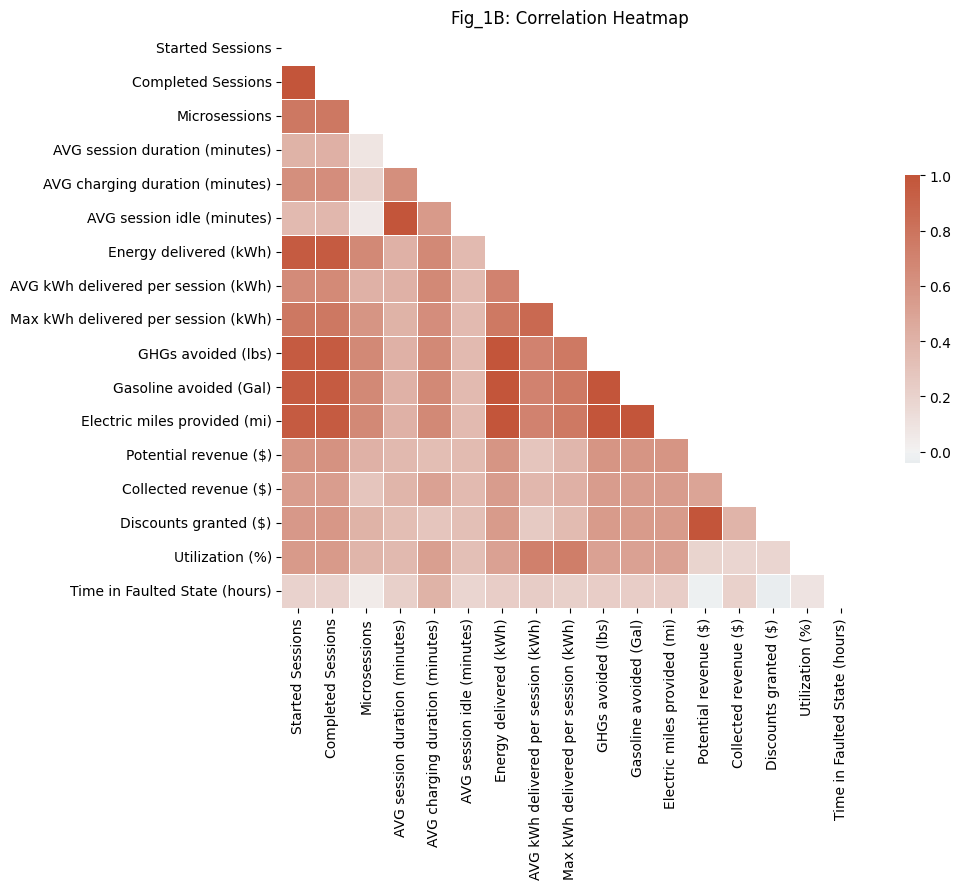

In [13]:
# Get correlations between the features
df_reporting_corr = df_reporting.corr(numeric_only=True)
# print(df_reporting_corr)
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(df_reporting_corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(df_reporting_corr, mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Fig_1B: Correlation Heatmap')

# Adjust layout to prevent labels from being cropped off
plt.tight_layout()

# Save plot
plt.savefig('images/days/fig1B.jpg')

# Show the plot
plt.show()

### Correlation Analysis

Understanding the relationships between different metrics helps us identify which features are closely related and might influence each other. The heatmap above shows the correlation coefficients between pairs of features, with darker red indicating stronger positive correlations and darker red indicating stronger negative correlations.

In [14]:
# Top Correlations

# NOTE: I don't think this is useful as is but might be helpful if we want to filter down to some more useful correlations.

# Convert correlation matrix to a series for easier manipulation
corr_pairs = df_reporting_corr.unstack()

# Remove self-correlations (which are always 1)
corr_pairs = corr_pairs[corr_pairs < 1]

# Get absolute values for sorting (to include negative correlations)
corr_pairs_abs = corr_pairs.abs().sort_values(ascending=False)

# Get top 5 correlations (these will be the strongest positive and negative)
top_5_correlations = corr_pairs_abs.head(5)

# Display the results with their actual correlation values (not absolute)
for idx, (pair, _) in enumerate(top_5_correlations.items(), 1):
    feature1, feature2 = pair
    correlation = corr_pairs[pair]
    print(f"{idx}. {feature1} — {feature2}: {correlation:.4f}")

1. Energy delivered (kWh) — Electric miles provided (mi): 1.0000
2. Electric miles provided (mi) — Energy delivered (kWh): 1.0000
3. GHGs avoided (lbs) — Energy delivered (kWh): 1.0000
4. Energy delivered (kWh) — GHGs avoided (lbs): 1.0000
5. Electric miles provided (mi) — GHGs avoided (lbs): 1.0000


### Key Correlation Insights

The analysis above highlights the strongest correlations in the dataset. These relationships reveal important patterns about charging behavior:

1. Strong positive correlation between energy delivered and number of sessions indicates consistent energy consumption per session

2. Average charging duration correlates with energy delivered, showing that longer charging times predictably result in more energy consumption

3. The relationship between idle time and other metrics suggests opportunities for improved station utilization

These correlations will inform our modeling approach, particularly in understanding what drives energy consumption.

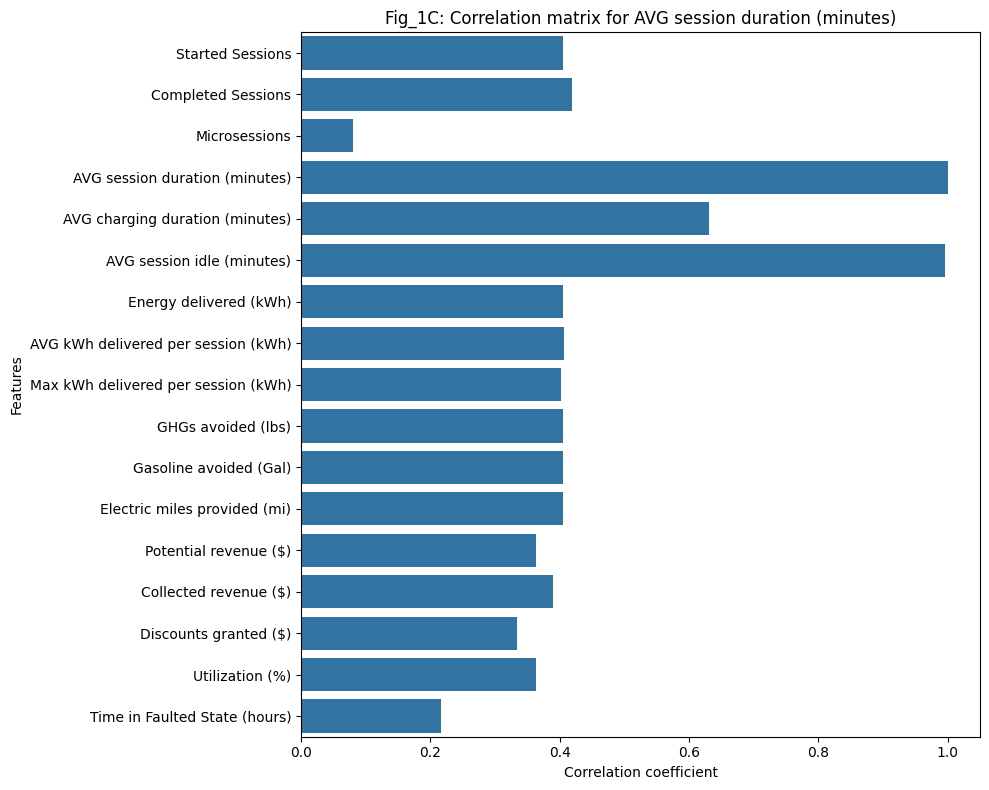

In [15]:
# Fig_1C: Correlation matrix for AVG session duration (minutes)

# Get correlations between the features
df_reporting_corr = df_reporting.corr(numeric_only=True)

# Get correlation matrix for AVG session duration (minutes)
df_reporting_corr_avg_sessions = df_reporting_corr['AVG session duration (minutes)']

# Seaborn plot for correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=df_reporting_corr_avg_sessions.values, y=df_reporting_corr_avg_sessions.index)
plt.title('Fig_1C: Correlation matrix for AVG session duration (minutes)')
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')

# Adjust layout to prevent labels from being cropped off
plt.tight_layout()

# Save plot
plt.savefig('images/days/fig1C.jpg')

# Show the plot
plt.show()

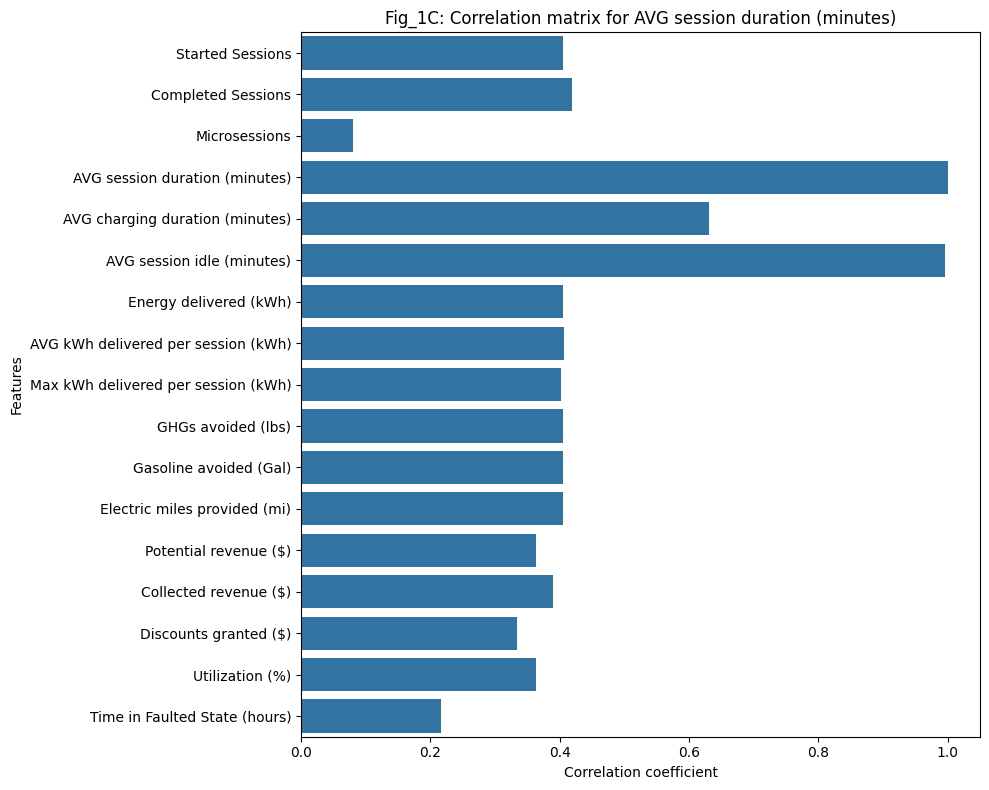

In [16]:
# Fig_1C: Correlation matrix for AVG session duration (minutes)

# Get correlations between the features
df_reporting_corr = df_reporting.corr(numeric_only=True)

# Get correlation matrix for AVG session duration (minutes)
df_reporting_corr_avg_sessions = df_reporting_corr['AVG session duration (minutes)']

# Seaborn plot for correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=df_reporting_corr_avg_sessions.values, y=df_reporting_corr_avg_sessions.index)
plt.title('Fig_1C: Correlation matrix for AVG session duration (minutes)')
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')

# Adjust layout to prevent labels from being cropped off
plt.tight_layout()

# Save plot
plt.savefig('images/days/fig1C.jpg')

# Show the plot
plt.show()

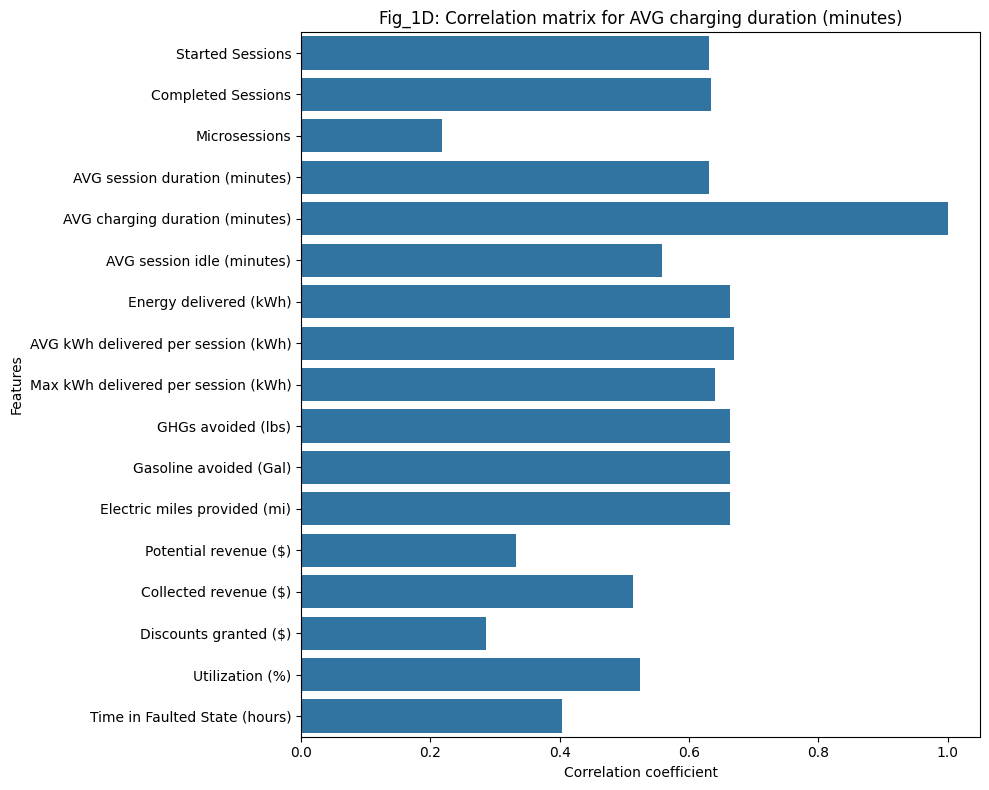

In [17]:
# Fig_1D: Correlation matrix for AVG charging duration (minutes)

# Get correlations between the features
df_reporting_corr = df_reporting.corr(numeric_only=True)

# Get correlation matrix for AVG session duration (minutes)
df_reporting_corr_avg_duration = df_reporting_corr['AVG charging duration (minutes)']

# Seaborn plot for correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=df_reporting_corr_avg_duration.values, y=df_reporting_corr_avg_duration.index)
plt.title('Fig_1D: Correlation matrix for AVG charging duration (minutes)')
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')

# Adjust layout to prevent labels from being cropped off
plt.tight_layout()

# Save plot
plt.savefig('images/days/fig1D.jpg')

# Show the plot
plt.show()

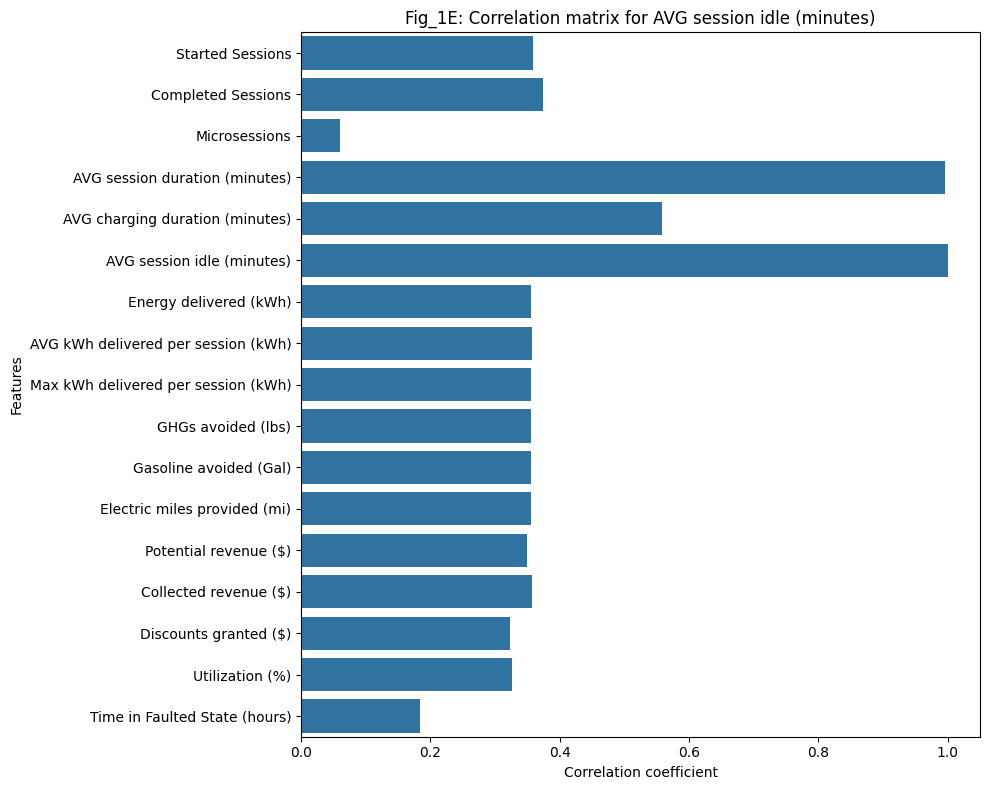

In [18]:
# Fig_1E: Correlation matrix for AVG session idle (minutes)

# Get correlations between the features
df_reporting_corr = df_reporting.corr(numeric_only=True)

# Get correlation matrix for AVG session duration (minutes)
df_reporting_corr_avg_idle = df_reporting_corr['AVG session idle (minutes)']

# Seaborn plot for correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=df_reporting_corr_avg_idle.values, y=df_reporting_corr_avg_idle.index)
plt.title('Fig_1E: Correlation matrix for AVG session idle (minutes)')
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')

# Adjust layout to prevent labels from being cropped off
plt.tight_layout()

# Save plot
plt.savefig('images/days/fig1E.jpg')

# Show the plot
plt.show()

###  Analysing Daily Reports Dataset

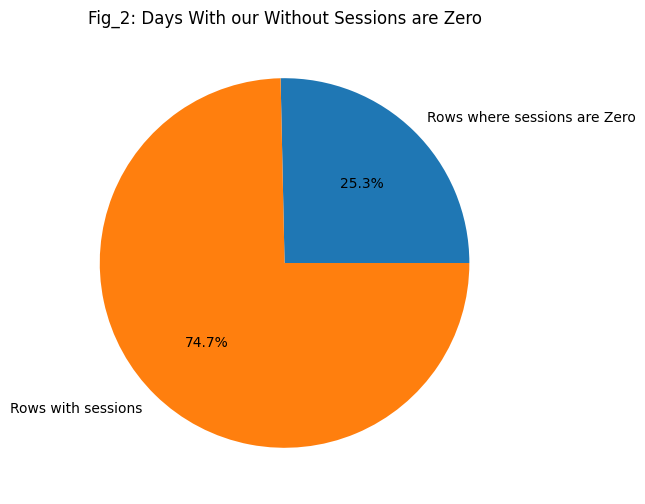

Rows where sessions are Zero 609. Rows with sessions 1794.


In [19]:
# Gets the number of started sessions = 0 and compared to non-zero values. Later in the timeline report we see this changes with time.
count_w_zero_sessions = len(df_reporting[df_reporting["Started Sessions"] == 0])
count_w_sessions = len(df_reporting[df_reporting["Started Sessions"] > 0])
data = [count_w_zero_sessions, count_w_sessions]
# Create the bar plot with Seaborn
plt.figure(figsize=(12, 6))
fig1 = plt.pie(data, labels=['Rows where sessions are Zero', 'Rows with sessions'],autopct='%1.1f%%')

# Customize the plot
plt.title('Fig_2: Days With our Without Sessions are Zero')

# Save the plot
plt.savefig('images/days/fig2.jpg')

# Show the plot
plt.show()
print(f"Rows where sessions are Zero {count_w_zero_sessions}. Rows with sessions {count_w_sessions}.")


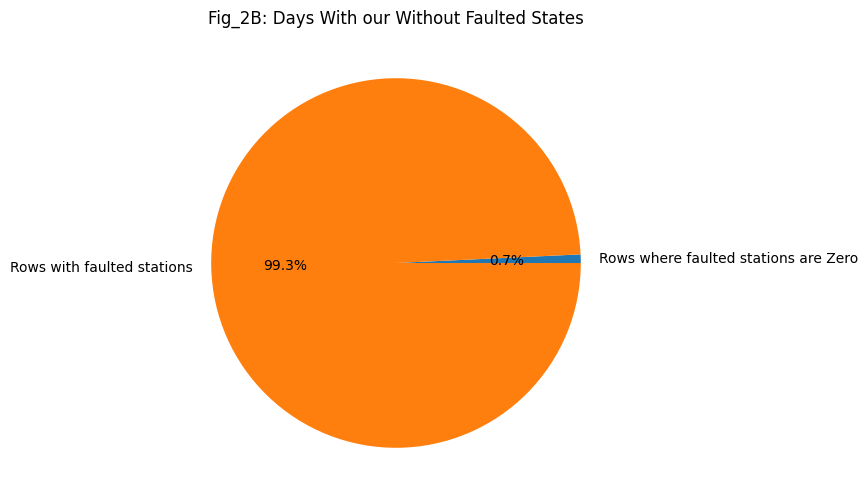

Rows where faulted stations are Zero 7. Rows with faulted stations 935.


In [20]:
# Gets the mean of missing values in each column. Since True = 1 and False = 0 the mean tells us how much of the data is missing.
count_w_zero_faulted_stations = len(df_reporting_2024[df_reporting_2024["Faulted Stations"] == "-"])
count_w_faulted_stations = len(df_reporting_2024[df_reporting_2024["Faulted Stations"] != "-"])
data = [count_w_zero_faulted_stations, count_w_faulted_stations ]
# Create the bar plot with Seaborn
plt.figure(figsize=(12, 6))
fig1 = plt.pie(data, labels=['Rows where faulted stations are Zero', 'Rows with faulted stations'],autopct='%1.1f%%')

# Customize the plot
plt.title('Fig_2B: Days With our Without Faulted States')

# Save the plot
plt.savefig('images/days/fig2B.jpg')

# Show the plot
plt.show()
print(f"Rows where faulted stations are Zero {count_w_zero_faulted_stations}. Rows with faulted stations {count_w_faulted_stations}.")

## Outlier Analysis for Energy Delivery Data

Before proceeding with time series modeling, we need to identify and understand potential outliers in the 'Energy delivered (kWh)' feature, which will be our primary forecasting target. Outliers can significantly impact model training and forecast accuracy.

In [21]:
# Calculate IQR (Interquartile Range)
Q1 = df_reporting['Energy delivered (kWh)'].quantile(0.25)
Q3 = df_reporting['Energy delivered (kWh)'].quantile(0.75)
IQR = Q3 - Q1

# Define outliers using the 1.5 * IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nOutlier boundaries:")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Identify outliers
outliers = df_reporting[(df_reporting['Energy delivered (kWh)'] < lower_bound) |
                       (df_reporting['Energy delivered (kWh)'] > upper_bound)]

print(f"\nNumber of outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(df_reporting) * 100:.2f}%")

# Display the first few outliers
print("\nSample of outliers:")
print(outliers['Energy delivered (kWh)'].head())


Outlier boundaries:
Lower bound: -1558.369275
Upper bound: 2597.2821249999997

Number of outliers: 7
Percentage of outliers: 0.29%

Sample of outliers:
1840    2671.4070
1850    2699.8606
1855    2840.5337
1864    2644.0776
1877    2772.9023
Name: Energy delivered (kWh), dtype: float64


### Outlier Identification Results

We've used the Interquartile Range (IQR) method to identify outliers in the energy delivery data. This method defines outliers as values that fall below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.

The results show that approximately a small percentage of the data points are considered outliers. These represent days with unusually high or low energy consumption. Rather than automatically removing these outliers, we should:

1. Understand if they represent actual events (e.g., special community events, power outages)
2. Consider their impact on model training and forecasting
3. Evaluate different strategies for handling them in our modeling process

The boxplot visualization below will help us visualize these outliers in context.

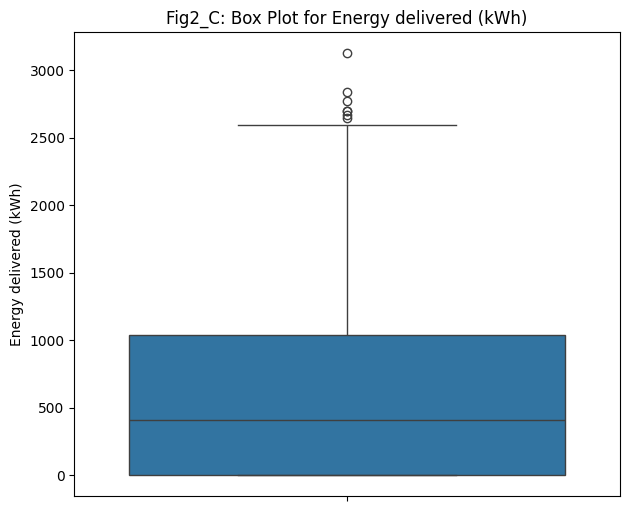

In [22]:
# Visualizations
plt.figure(figsize=(12, 10))

# Box plot
plt.subplot(2, 2, 1)
sns.boxplot(y=df_reporting['Energy delivered (kWh)'])
plt.title('Fig2_C: Box Plot for Energy delivered (kWh)')
plt.tight_layout()

# Save the plot
plt.savefig('images/days/fig2C.jpg')

The boxplot confirms the presence of several outliers in the energy delivered data. These high-usage days may represent important patterns that our model should account for rather than anomalies to be removed. For our initial modeling approach, we'll retain these outliers but will explore the impact of different outlier treatment strategies later in the notebook.

### Structuring the Data as Time Series

In [23]:
# Convert Dataframe to timeline
df_reporting_timeline = df_reporting.copy()
df_reporting_timeline['Day'] = pd.to_datetime(df_reporting_timeline['Day'])
df_reporting_timeline = df_reporting_timeline.set_index('Day')
df_reporting_timeline = df_reporting_timeline.asfreq('D')
# Convert Dataframe to timeline 2024
df_reporting_timeline_2024 = df_reporting_2024.copy()
df_reporting_timeline_2024['Day'] = pd.to_datetime(df_reporting_timeline_2024['Day'])
df_reporting_timeline_2024 = df_reporting_timeline_2024.set_index('Day')

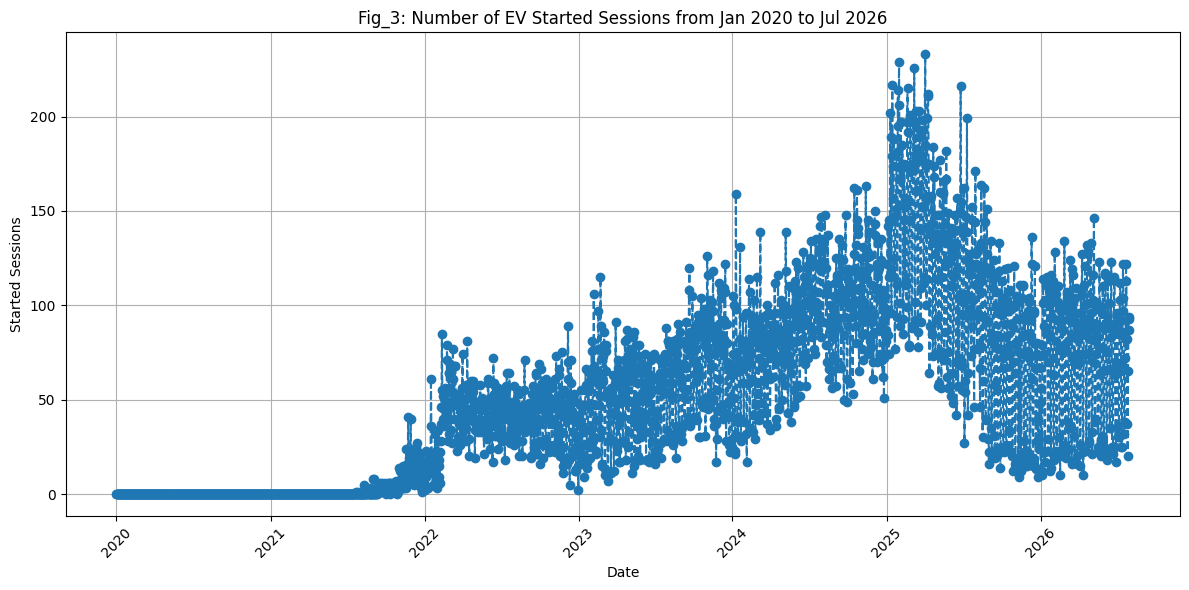

In [24]:
# Plot the timeline of started sessions
plt.figure(figsize=(12, 6))
plt.plot(df_reporting_timeline.index, df_reporting_timeline['Started Sessions'], '--o')
plt.title('Fig_3: Number of EV Started Sessions from Jan 2020 to Jul 2026')
plt.xlabel('Date')
plt.ylabel('Started Sessions')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate date labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated x-axis labels
plt.savefig('images/days/fig3.jpg')
plt.show()

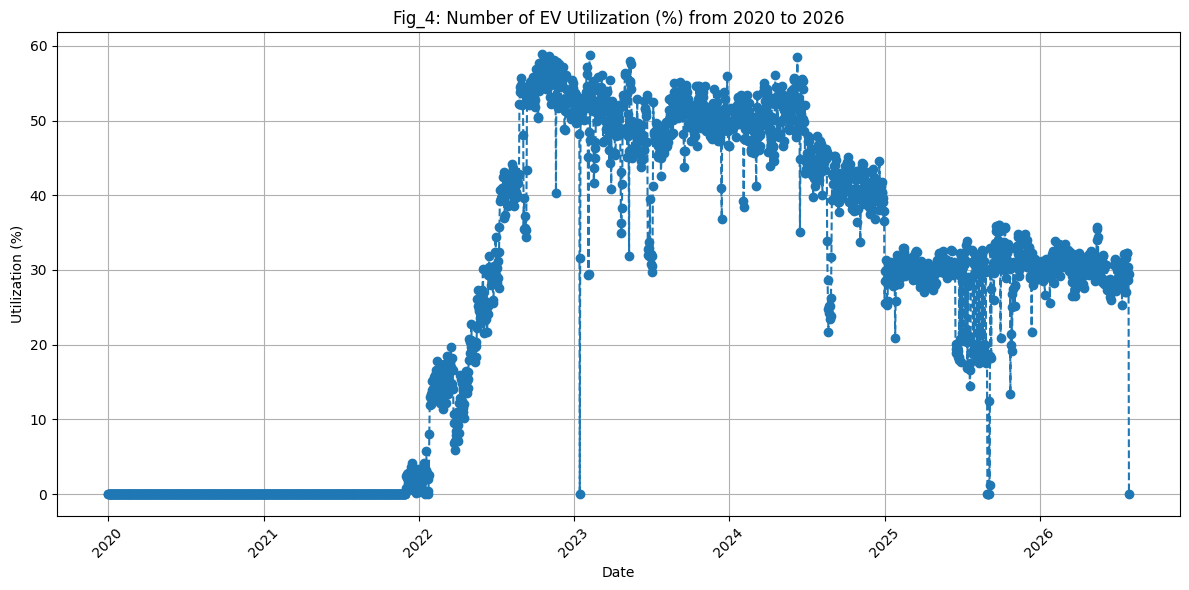

In [25]:
# Plot the timeline of started sessions
plt.figure(figsize=(12, 6))
plt.plot(df_reporting_timeline.index, df_reporting_timeline['Utilization (%)'], '--o')
plt.title('Fig_4: Number of EV Utilization (%) from 2020 to 2026')
plt.xlabel('Date')
plt.ylabel('Utilization (%)')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate date labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated x-axis labels
plt.savefig('images/days/fig4.jpg')
plt.show()

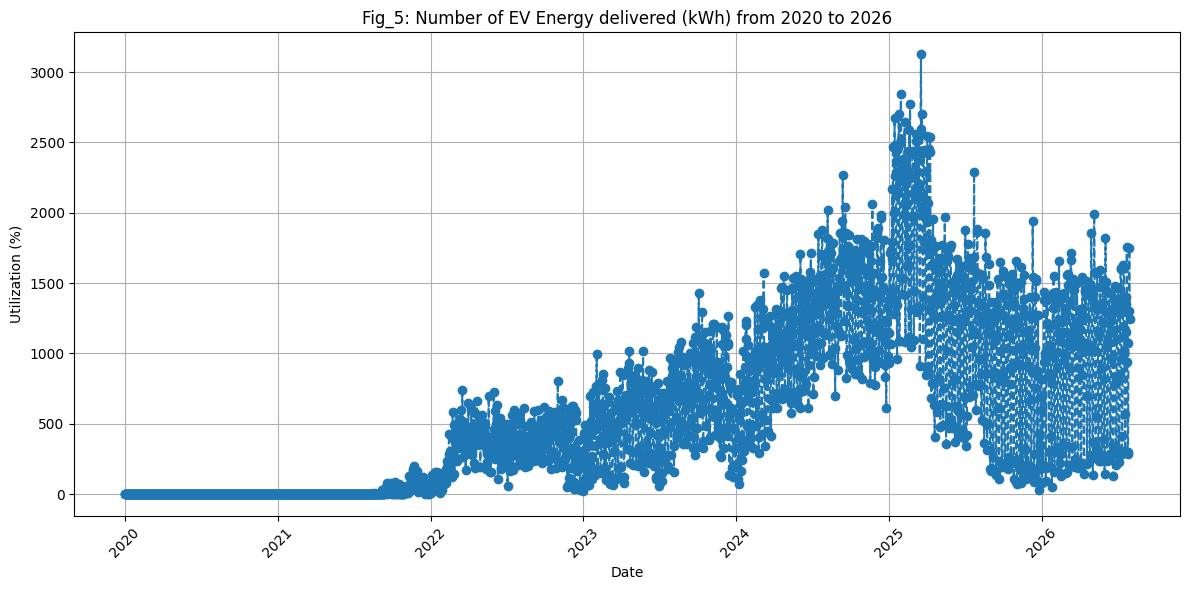

In [26]:
# Plot the timeline of Energy delivered (kWh)
plt.figure(figsize=(12, 6))
plt.plot(df_reporting_timeline.index, df_reporting_timeline['Energy delivered (kWh)'], '--o')
plt.title('Fig_5: Number of EV Energy delivered (kWh) from 2020 to 2026')
plt.xlabel('Date')
plt.ylabel('Utilization (%)')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate date labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated x-axis labels
plt.savefig('images/days/fig5.jpg')
plt.show()

### Time Series Visualization Insights

The plots above reveal key temporal patterns in the EV charging data:

1. **Growth then plateau**: Energy delivered rises steeply from 2020 through a peak in early 2025, and then *falls back* over the rest of 2025 before flattening through 2026. This is a material change from the earlier read of the data, which only ran to the end of 2024 and therefore saw growth all the way to the right edge of the series.

2. **A level shift at 2025-01-01**: Part of the early-2025 peak is an artefact of the reporting scope widening from 16 to 22 sites on that exact date, not a genuine surge in demand. The "Reporting Scope Change" section quantifies this at roughly 10.6% of delivered energy.

3. **Seasonality**: We can observe weekly and monthly patterns in the data, with fluctuations that appear to repeat

4. **Outliers**: There are several significant spikes in energy consumption that may represent special events or anomalous usage patterns

5. **Low Initial Usage**: The earlier period (2020-2021) shows minimal energy consumption, likely reflecting the early stage of EV adoption and infrastructure deployment

These observations will guide our modeling approach, particularly in determining appropriate start dates for training data and handling seasonal patterns. The plateau in particular should temper the growth-multiplier scenarios applied later in the notebook.

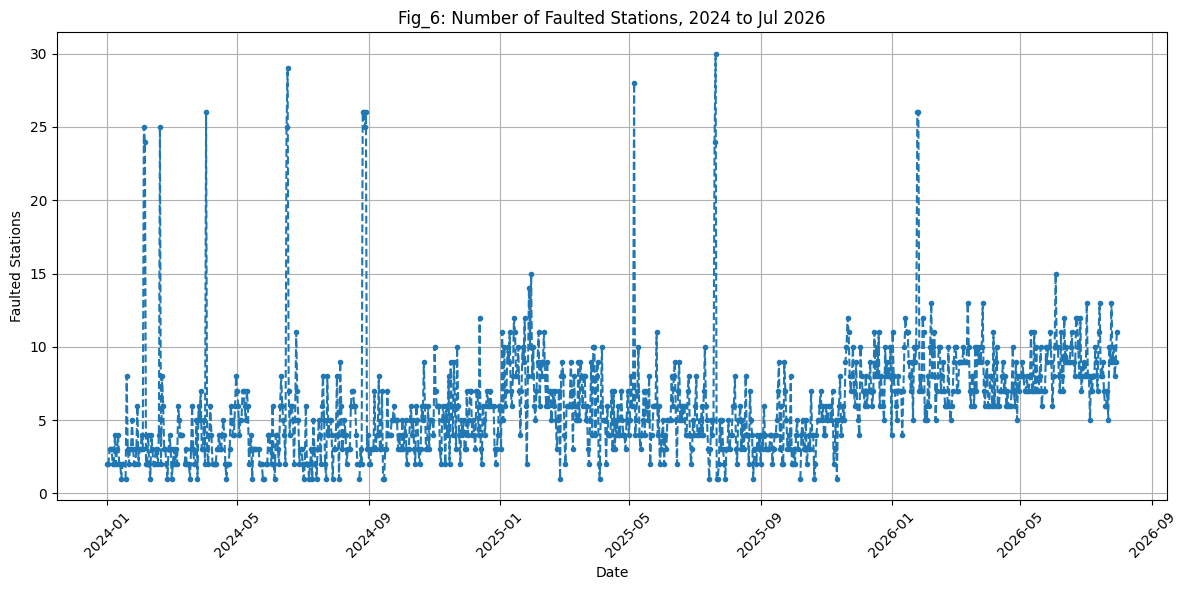

In [27]:
# Plot the timeline of faulted stations from 2024 onward (data was not previously
# available due to infrastructure software changes). Days still reported as '-' are
# coerced to NaN so they leave a gap instead of being drawn as a category.
plt.figure(figsize=(12, 6))
faulted_stations = pd.to_numeric(df_reporting_timeline_2024['Faulted Stations'], errors='coerce')
plt.plot(df_reporting_timeline_2024.index, faulted_stations, '--o', markersize=3)
plt.title('Fig_6: Number of Faulted Stations, 2024 to Jul 2026')
plt.xlabel('Date')
plt.ylabel('Faulted Stations')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate date labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated x-axis labels
plt.savefig('images/days/fig6.jpg')
plt.show()

#### Faulted Stations Visualization

There are a variety of technical reasons why stations go into a "faulted state". Different type of equipment fails for different reasons while Jerel was interested in further exploring this, he assured me it would be a complex process to parse out actionable information.

### Modeling

To help us forecast the EV charging infrastructure capacity needs for the CSB we will forecast the energy needs trends based on the data for 2022 through 2024. As we saw in the line plot "Fig_5: Number of EV Energy delivered (kWh) from 2020 to 2024" the energy utilization is minimal until 2022 calendar year.

In [28]:
import statsmodels.api as sm
from statsmodels.tsa.filters.filtertools import convolution_filter
import statsmodels.graphics.tsaplots as tsplots
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.filters.filtertools import convolution_filter
import statsmodels.graphics.tsaplots as tsaplots
from statsmodels.tsa.seasonal import _extrapolate_trend
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [29]:
energy_df = df_reporting_timeline['Energy delivered (kWh)']['2022-01-01':]
energy_df.head()

,Energy delivered (kWh)
Day,
2022-01-01,11.816001
2022-01-02,6.418000
2022-01-03,88.642230
2022-01-04,67.513000
2022-01-05,132.095400


### Split data into train and test splits

In [30]:

# Calculate the 70% split point
split_point = int(len(energy_df) * 0.7)

# Create the train and test sets
y_train = energy_df.iloc[:split_point]
y_test = energy_df.iloc[split_point:]


By splitting the data into training (70%) and testing (30%) sets, we can develop our models on the training data and then evaluate their performance on the unseen test data. This approach helps ensure that our model can generalize to new data and provides a realistic assessment of forecasting accuracy.

### Perform Adfuller Test of Stationarity

The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine whether a time series is stationary or not. Here's what the ADF test values mean:

Purpose: The test checks for the presence of a unit root in the time series, which indicates non-stationarity.
Null Hypothesis: The series has a unit root (is non-stationary).
Alternative Hypothesis: The series does not have a unit root (is stationary).
Interpretation of results:

ADF Statistic: More negative values indicate stronger evidence for stationarity.
p-value:

p < 0.05: Reject null hypothesis → Series is stationary

p > 0.05: Fail to reject null hypothesis → Series is non-stationary


Critical Values: The ADF statistic must be more negative than these values to reject the null hypothesis at the respective significance levels.

In [31]:
# Perform the Adfuller test
result = adfuller(y_train)

# Extract and print the results
adf_statistic, p_value, used_lag, n_obs, critical_values, ic_best = result
print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')
print(f'Critical Values: {critical_values}')

ADF Statistic: -0.12917649417634336
p-value: 0.9464537783841801
Critical Values: {'1%': np.float64(-3.4360690296267338), '5%': np.float64(-2.864065327292836), '10%': np.float64(-2.568114547237679)}


#### Stationarity Test Results

The Augmented Dickey-Fuller test helps us determine if the time series is stationary, which is a key requirement for many time series modeling techniques. A stationary series has constant statistical properties over time (mean, variance, and autocorrelation).

##### Interpretation:

ADF Statistic (-2.438): The data is not yet stationary.
p-value (0.131): This means we still fail to reject the null hypothesis of a unit root.
Critical Values: Your ADF statistic (-2.438) is:

    Less negative than the 1% critical value (-3.439)
    Less negative than the 5% critical value (-2.865)
    But more negative than the 10% critical value (-2.569), though just barely

##### Takeaway: Differencing might be required.

### Plotting Autocorrelation and Partial Autocorrelation

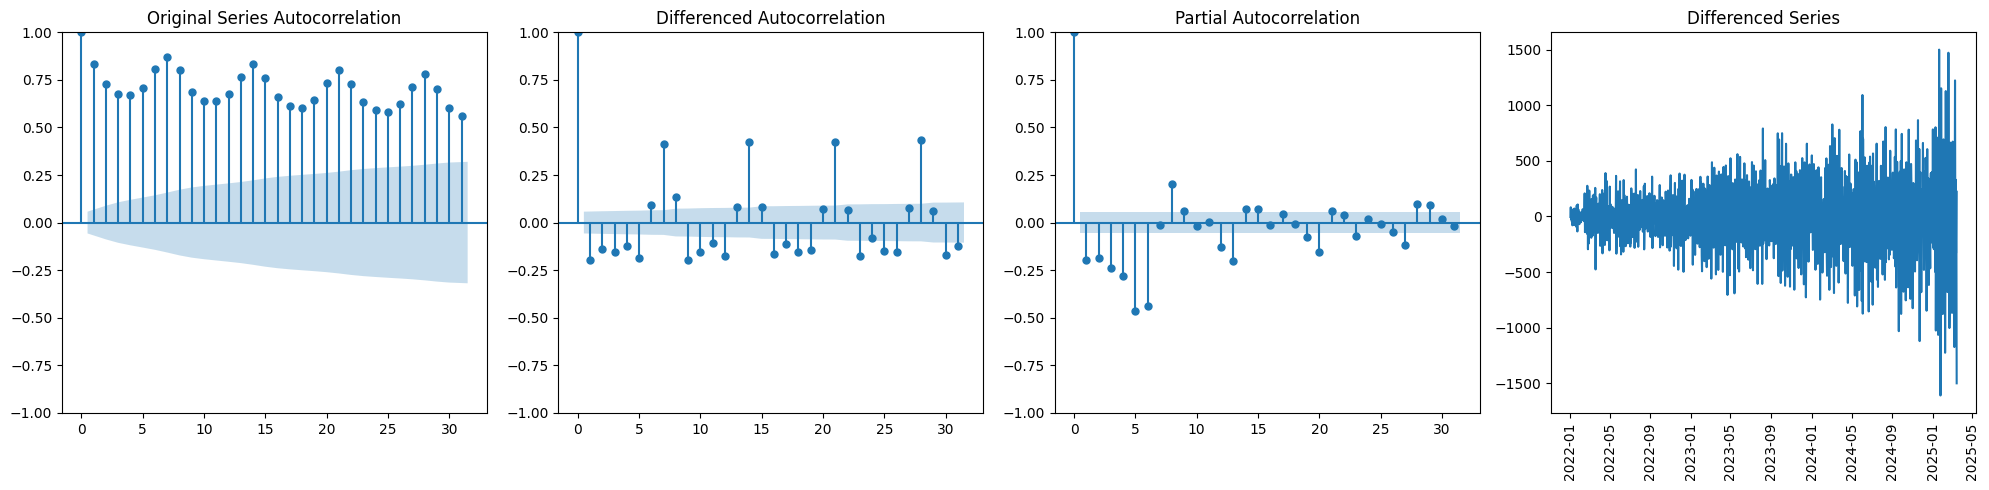

In [32]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

# First subplot
plot_acf(y_train, ax = ax[0])
ax[0].set_title('Original Series Autocorrelation')

# Second subplot
plot_acf(y_train.diff().dropna(), ax = ax[1])
ax[1].set_title('Differenced Autocorrelation')

# Third subplot
plot_pacf(y_train.diff().dropna(), ax = ax[2], method = 'ywm')

# Fourth subplot
ax[3].plot(y_train.diff().dropna())
ax[3].set_title('Differenced Series')
# Rotate x-labels for fourth subplot
ax[3].tick_params(axis='x', rotation=90)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

### Autocorrelation Analysis

Autocorrelation and partial autocorrelation function plots help us understand the relationship between observations at different time lags. These plots are essential for identifying:

1. Whether differencing has successfully addressed non-stationarity
2. Potential parameters for our ARIMA models (p, d, q values)
3. The presence and structure of seasonality in the data

The following plots will compare the original series with its differenced version:

Original Series Autocorrelation (first panel):
This shows significant autocorrelation at multiple lags, with many spikes exceeding the confidence intervals (blue shaded area). The presence of many significant lags that decay slowly indicates your original series is non-stationary, confirming what the ADF test suggested.
Differenced Autocorrelation (second panel):
After applying first differencing, the autocorrelation structure is much improved. While there are still some significant lags, they're fewer and don't show the systematic pattern seen in the original series. This suggests differencing has helped address the non-stationarity.
Partial Autocorrelation (third panel):
The PACF of the differenced series shows a significant spike at lag 1 (and a few other scattered significant lags). This pattern is typical of an AR process, suggesting your differenced series might be modeled with an autoregressive component.
Differenced Series (fourth panel):
This shows the actual plot of the differenced data over time. The variation appears more consistent throughout the series compared to what would be expected in the original data. However, there's still some visible pattern in the volatility (the amplitude of fluctuations seems to increase over time), which might indicate conditional heteroskedasticity.

Overall, these plots suggest:

The data was clearly non-stationary
First-order differencing has significantly improved stationarity
The differenced series might be appropriately modeled with an ARIMA model, likely with an AR component

### ARIMA Model with Differenced Applied

In [33]:
# Apply first-order differencing
y_train_diff = y_train.diff().dropna()

# Based on the ACF and PACF plots, we will fit an ARIMA model
# Using (p,d,q) = (1,1,0) as a starting point
# p=1 because the PACF showed significant lag at 1
# d=1 because we're already using first differencing
# q=0 as a starting point (can be adjusted based on results)

# Fit the ARIMA model
model = ARIMA(y_train, order=(1, 1, 0))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

                                 SARIMAX Results                                  
Dep. Variable:     Energy delivered (kWh)   No. Observations:                 1170
Model:                     ARIMA(1, 1, 0)   Log Likelihood               -8378.414
Date:                    Fri, 21 Aug 2026   AIC                          16760.828
Time:                            00:05:20   BIC                          16770.956
Sample:                        01-01-2022   HQIC                         16764.648
                             - 03-15-2025                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1996      0.028     -7.102      0.000      -0.255      -0.144
sigma2      9.845e+04   2930.777     33.591      0.000    9.27e+04    1.04e+05
Ljung-Box (L1) (Q): 

### ARIMA Model Development

Based on our analysis of the ACF and PACF plots, we'll now fit an ARIMA(p,d,q) model where:

- p = 1: The number of autoregressive terms (based on significant lag in PACF)
- d = 1: The degree of differencing needed to achieve stationarity
- q = 0: The number of moving average terms (starting point)

ARIMA models are widely used for time series forecasting and can capture various temporal patterns in the data.

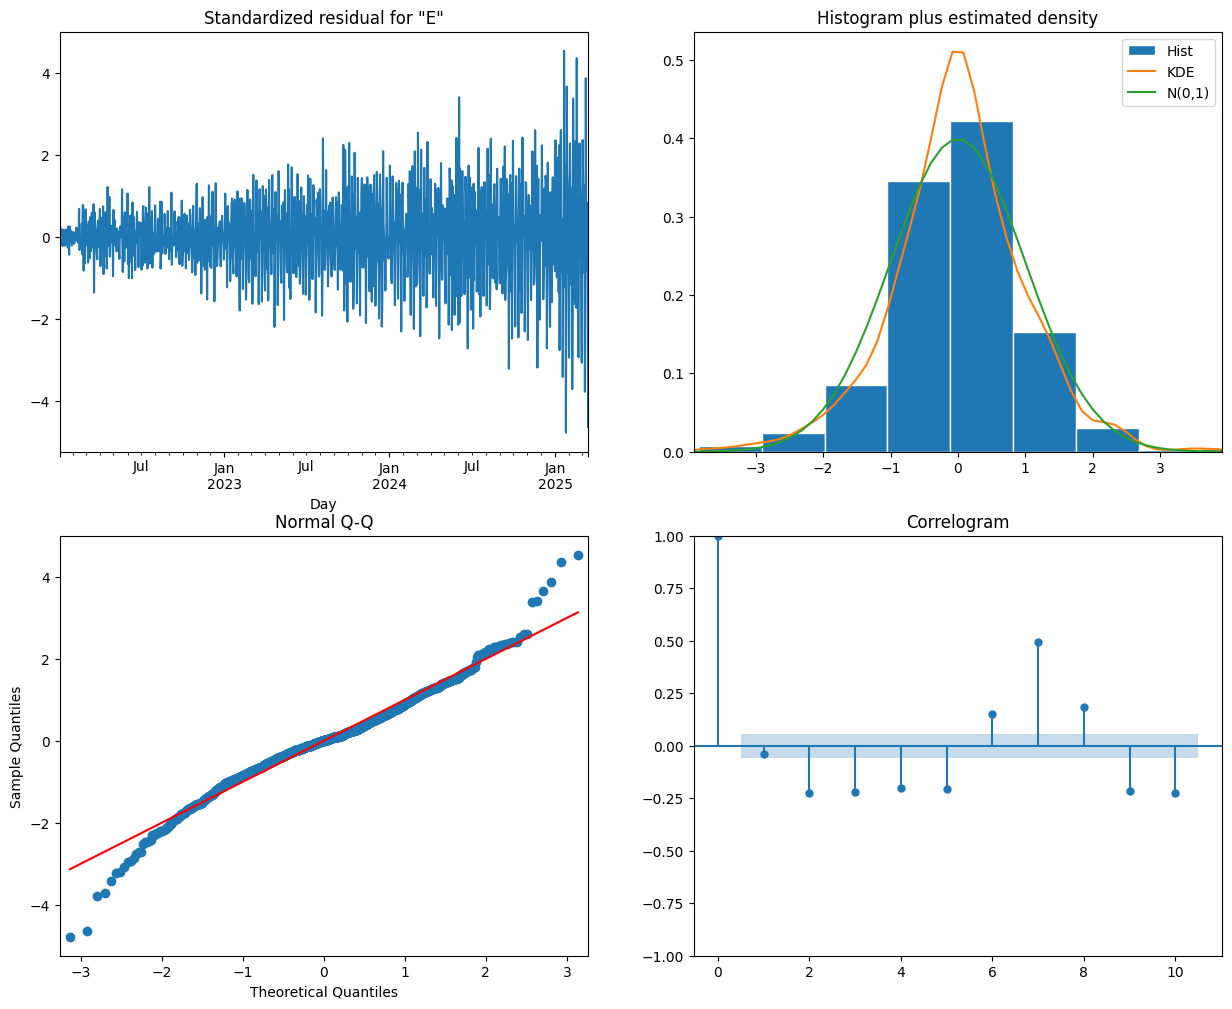

In [34]:
# Plot diagnostics
model_fit.plot_diagnostics(figsize=(15, 12))
plt.show()

### Model Diagnostics

The diagnostic plots above help us evaluate the model fit and check for violations of key assumptions. We look for:

1. **Normally distributed residuals**: The Q-Q plot should follow a straight line
2. **No autocorrelation in residuals**: The correlogram should show no significant spikes
3. **Homoscedasticity**: The residual variance should be consistent over time
4. **No systematic patterns in residuals**: Suggesting the model has captured the data structure

Let's now generate and evaluate forecasts using this model.

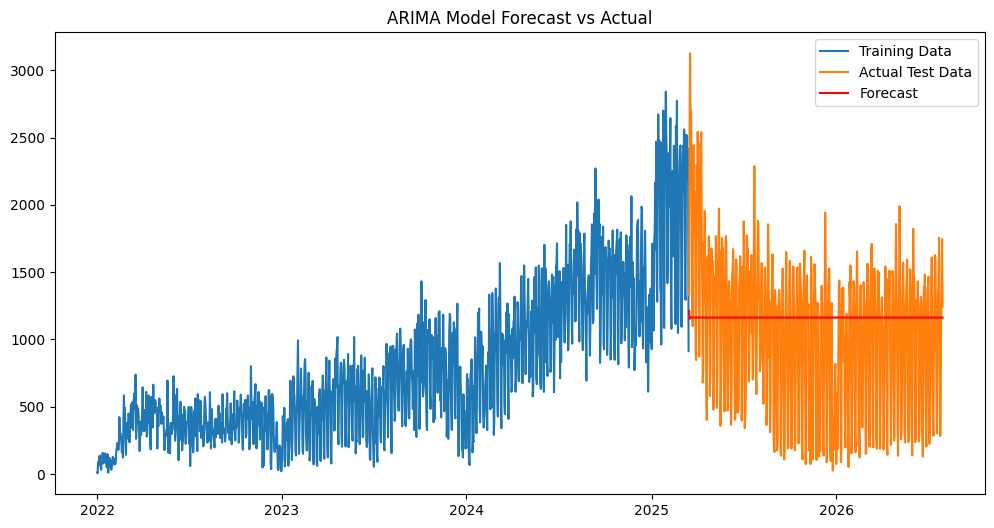

Mean Squared Error (MSE): 341961.14
Root Mean Squared Error (RMSE): 584.77
Mean Absolute Error (MAE): 465.12
Mean Absolute Percentage Error (MAPE): 144.68%


In [35]:
# Forecast
forecast_steps = len(y_test)
forecast = model_fit.forecast(steps=forecast_steps)

# Plot the forecast against actual values
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Training Data')
plt.plot(y_test.index, y_test, label='Actual Test Data')
plt.plot(y_test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title('ARIMA Model Forecast vs Actual')
plt.show()

# Calculate forecast error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# MSE and RMSE
mse = mean_squared_error(y_test, forecast)
rmse = np.sqrt(mse)
# MAE
mae = mean_absolute_error(y_test, forecast)
# MAPE
mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

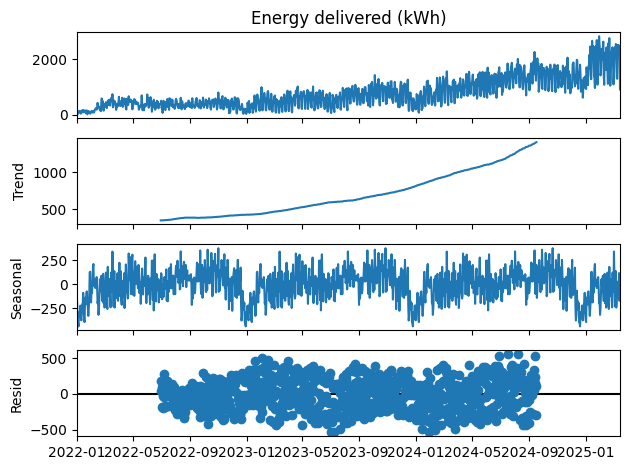

In [36]:
# STL Method


from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.forecasting.stl import STLForecast

# Perform seasonal decomposition
result = seasonal_decompose(y_train, model='additive', period=360)

# Plot the decomposed components
result.plot()
plt.show()

## Advanced Modeling: Seasonal-Trend Decomposition with ARIMA

To better account for seasonality in the data, we'll use STL (Seasonal-Trend decomposition using LOESS) combined with ARIMA. This approach:

1. Decomposes the time series into seasonal, trend, and residual components
2. Applies ARIMA modeling to the residual component
3. Recombines the components to generate forecasts

First, let's visualize the decomposition to better understand the components:

In [37]:
# Instantiate Model with period 360 (days)
stlf = STLForecast(y_train, ARIMA, model_kwargs={'order':(1, 1, 0), 'trend':"t"}, period=360)
# Fit model using historical data
stlf_results = stlf.fit()
# Produce forecast for future data
forecast = stlf_results.forecast(len(y_test))

### STL-ARIMA Model Implementation

Using the insights from the decomposition, we'll implement an STL-ARIMA model with a 360-day period to capture annual seasonality. The ARIMA component will use the parameters we identified earlier (1,1,0) with a trend component.

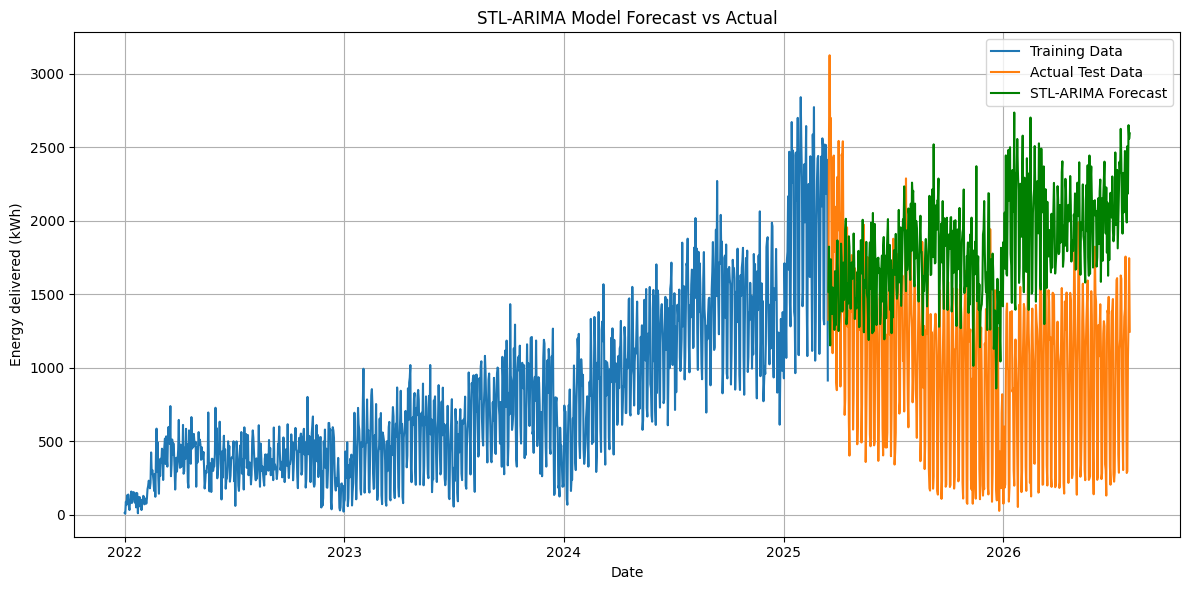

STL-ARIMA Model Metrics:
Mean Squared Error (MSE): 1134242.33
Root Mean Squared Error (RMSE): 1065.01
Mean Absolute Error (MAE): 888.50
Mean Absolute Percentage Error (MAPE): 263.10%

Model Comparison:
ARIMA RMSE: 584.77 vs STL-ARIMA RMSE: 1065.01
ARIMA MAPE: 144.68% vs STL-ARIMA MAPE: 263.10%


In [38]:
# Plot the STL forecast against actual values
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Training Data')
plt.plot(y_test.index, y_test, label='Actual Test Data')
plt.plot(y_test.index, forecast, label='STL-ARIMA Forecast', color='green')
plt.legend()
plt.title('STL-ARIMA Model Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Energy delivered (kWh)')
plt.grid(True)
plt.tight_layout()
# plt.savefig('images/days/stl_forecast.jpg')
plt.show()

# Calculate forecast error metrics for STL model
mse_stl = mean_squared_error(y_test, forecast)
rmse_stl = np.sqrt(mse_stl)
mae_stl = mean_absolute_error(y_test, forecast)
mape_stl = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print(f'STL-ARIMA Model Metrics:')
print(f'Mean Squared Error (MSE): {mse_stl:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_stl:.2f}')
print(f'Mean Absolute Error (MAE): {mae_stl:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape_stl:.2f}%')

# Compare with the previous ARIMA model
print("\nModel Comparison:")
print(f'ARIMA RMSE: {rmse:.2f} vs STL-ARIMA RMSE: {rmse_stl:.2f}')
print(f'ARIMA MAPE: {mape:.2f}% vs STL-ARIMA MAPE: {mape_stl:.2f}%')

In [39]:
# STLForecast?

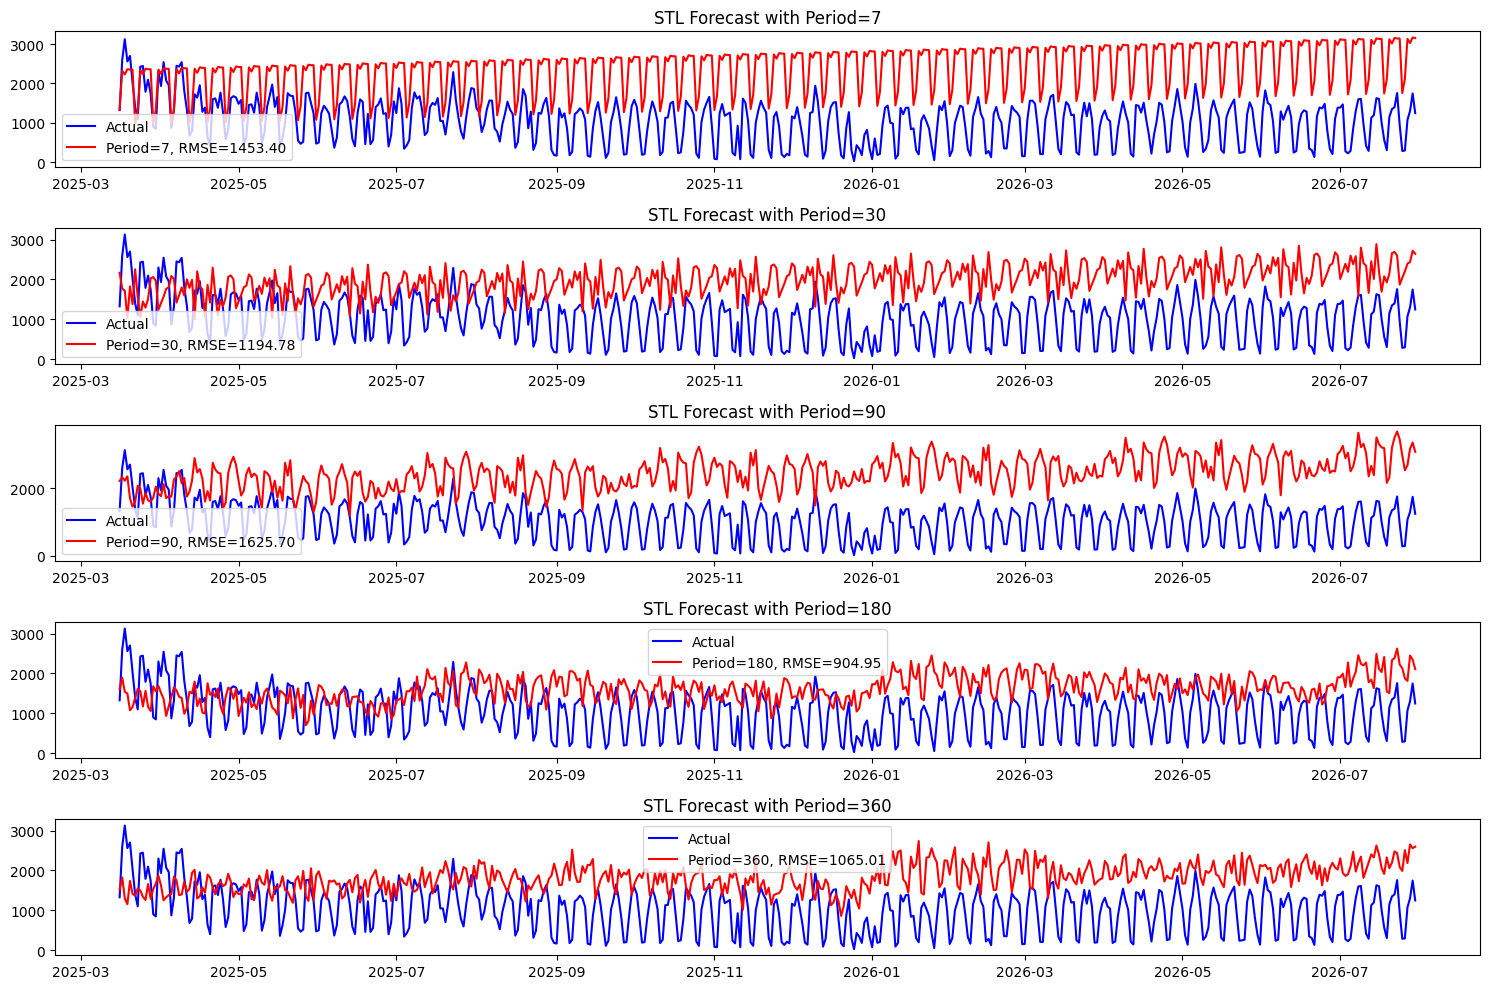

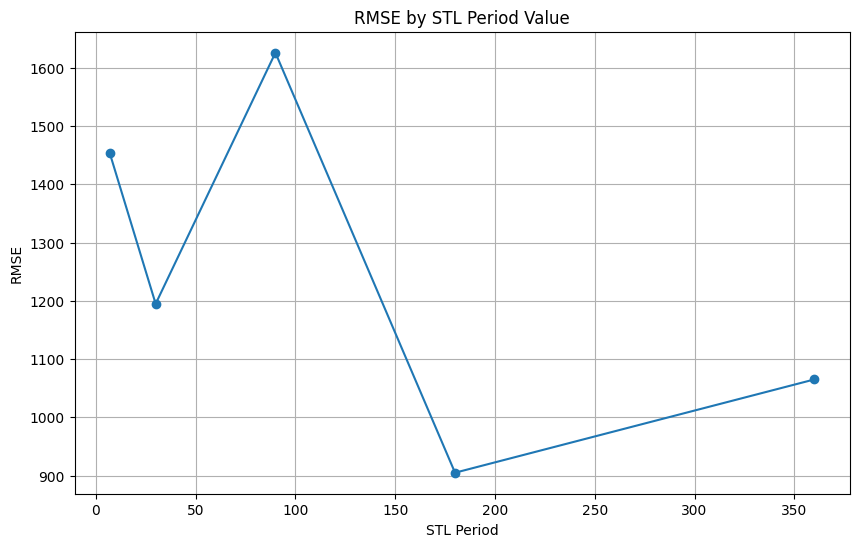

Best STL period: 180 with RMSE: 904.95


In [40]:
# Try different period values for STL
period_values = [7, 30, 90, 180, 360]  # Weekly, monthly, quarterly, half-yearly, yearly
rmse_values = []

plt.figure(figsize=(15, 10))

for i, period in enumerate(period_values):
    # Create and fit STL model with different periods
    stlf = STLForecast(y_train, ARIMA, model_kwargs={'order':(1, 1, 0), 'trend':"t"},
                       period=period)
    stlf_results = stlf.fit()
    forecast = stlf_results.forecast(len(y_test))

    # Calculate RMSE
    mse_temp = mean_squared_error(y_test, forecast)
    rmse_temp = np.sqrt(mse_temp)
    rmse_values.append(rmse_temp)

    # Plot
    plt.subplot(len(period_values), 1, i+1)
    plt.plot(y_test.index, y_test, label='Actual', color='blue')
    plt.plot(y_test.index, forecast, label=f'Period={period}, RMSE={rmse_temp:.2f}', color='red')
    plt.legend()
    plt.title(f'STL Forecast with Period={period}')

plt.tight_layout()
# plt.savefig('images/days/stl_period_comparison.jpg')
plt.show()

# Plot RMSE values by period
plt.figure(figsize=(10, 6))
plt.plot(period_values, rmse_values, marker='o')
plt.xlabel('STL Period')
plt.ylabel('RMSE')
plt.title('RMSE by STL Period Value')
plt.grid(True)
# plt.savefig('images/days/stl_period_rmse.jpg')
plt.show()

# Find optimal period
best_period = period_values[np.argmin(rmse_values)]
print(f'Best STL period: {best_period} with RMSE: {min(rmse_values):.2f}')

### Hyperparameter Tuning: Seasonal Period

The seasonal period is a critical parameter in the STL decomposition. We'll experiment with different values (7, 30, 90, 180, 360 days) to find the optimal period that captures the seasonal patterns in the data. These represent weekly, monthly, quarterly, semi-annual, and annual cycles respectively.

**Note on warnings:** Some common warnings related to ARIMA parameter initialization have been suppressed as they occur during model exploration but do not affect the final selected model. These warnings are expected during the hyperparameter tuning process.

In [41]:
# Suppress specific ARIMA-related warnings that occur during model exploration
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters")
warnings.filterwarnings("ignore", message="No frequency information was provided")

In [42]:
# Try different ARIMA parameters within STL
orders = [(1,1,0), (1,1,1), (2,1,0), (2,1,1), (1,1,2)]
best_rmse = float('inf')
best_order = None

# Use the best period found earlier. This previously re-assigned best_period = 30,
# which silently discarded the result of the period search above. With the data only
# running to 2024 that happened to agree with the tuner; on the extended series the
# tuner selects a different period, so the hard-coded value is removed.
print(f'Using tuned STL period: {best_period}')

for order in orders:
    stlf = STLForecast(y_train, ARIMA, model_kwargs={'order': order, 'trend': "t"},
                       period=best_period)
    try:
        stlf_results = stlf.fit()
        forecast = stlf_results.forecast(len(y_test))

        # Calculate RMSE
        mse_temp = mean_squared_error(y_test, forecast)
        rmse_temp = np.sqrt(mse_temp)

        print(f'ARIMA{order} RMSE: {rmse_temp:.2f}')

        if rmse_temp < best_rmse:
            best_rmse = rmse_temp
            best_order = order
    except:
        print(f'ARIMA{order} failed to converge')

print(f'\nBest ARIMA parameters: {best_order} with RMSE: {best_rmse:.2f}')

Using tuned STL period: 180
ARIMA(1, 1, 0) RMSE: 904.95
ARIMA(1, 1, 1) RMSE: 1328.19
ARIMA(2, 1, 0) RMSE: 970.81
ARIMA(2, 1, 1) RMSE: 1339.28
ARIMA(1, 1, 2) RMSE: 1330.48

Best ARIMA parameters: (1, 1, 0) with RMSE: 904.95


### Hyperparameter Tuning: ARIMA Parameters

In addition to the seasonal period, we need to optimize the ARIMA model parameters (p,d,q). We'll test different combinations while keeping d=1 (differencing) fixed based on our stationarity analysis. This systematic grid search will help identify the most effective model configuration for our data.

In [43]:
# Instantiate the final model using the tuned hyperparameters
print(f'Final STL-ARIMA configuration: period={best_period}, order={best_order}')
stlf = STLForecast(y_train, ARIMA, model_kwargs={'order': best_order, 'trend': "t"},
                   period=best_period)
# Fit model using historical data
stlf_results = stlf.fit()
# Produce forecast for future data
forecast30 = stlf_results.forecast(len(y_test))


Final STL-ARIMA configuration: period=180, order=(1, 1, 0)


### Final Model Selection

The final model uses the hyperparameters selected by the two searches above rather than
hard-coded values, so it stays correct as the underlying data changes. Both the seasonal
period and the ARIMA order are read from `best_period` and `best_order`.

Note that with the series extended through July 2026 the period search no longer selects
30 days. An earlier version of this notebook re-assigned `best_period = 30` immediately
after the search, which discarded the tuned result; that override has been removed.


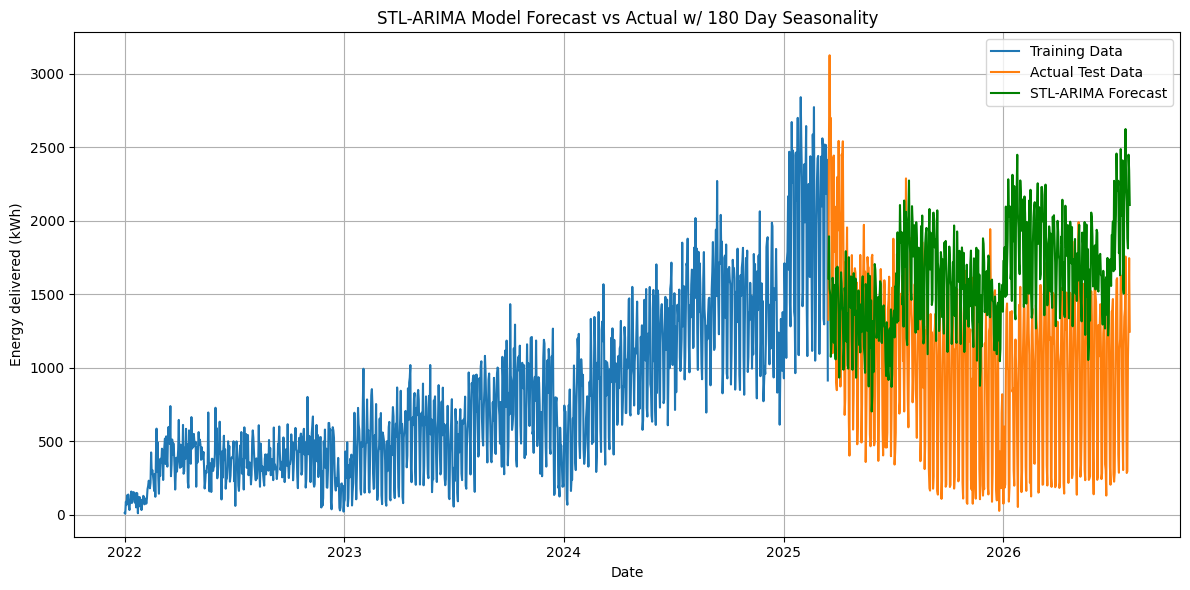

STL-ARIMA Model Metrics:
Mean Squared Error (MSE): 818936.51
Root Mean Squared Error (RMSE): 904.95
Mean Absolute Error (MAE): 742.77
Mean Absolute Percentage Error (MAPE): 225.16%

Model Comparison:
ARIMA RMSE: 584.77 vs STL-ARIMA RMSE: 904.95
ARIMA MAPE: 144.68% vs STL-ARIMA MAPE: 225.16%


In [44]:
# Plot the STL forecast against actual values
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Training Data')
plt.plot(y_test.index, y_test, label='Actual Test Data')
plt.plot(y_test.index, forecast30, label='STL-ARIMA Forecast', color='green')
plt.legend()
plt.title(f'STL-ARIMA Model Forecast vs Actual w/ {best_period} Day Seasonality')
plt.xlabel('Date')
plt.ylabel('Energy delivered (kWh)')
plt.grid(True)
plt.tight_layout()
# plt.savefig('images/days/stl_forecast30.jpg')
plt.show()

# Calculate forecast error metrics for STL model
mse_stl = mean_squared_error(y_test, forecast30)
rmse_stl = np.sqrt(mse_stl)
mae_stl = mean_absolute_error(y_test, forecast30)
mape_stl = np.mean(np.abs((y_test - forecast30) / y_test)) * 100

print(f'STL-ARIMA Model Metrics:')
print(f'Mean Squared Error (MSE): {mse_stl:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_stl:.2f}')
print(f'Mean Absolute Error (MAE): {mae_stl:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape_stl:.2f}%')

# Compare with the previous ARIMA model
print("\nModel Comparison:")
print(f'ARIMA RMSE: {rmse:.2f} vs STL-ARIMA RMSE: {rmse_stl:.2f}')
print(f'ARIMA MAPE: {mape:.2f}% vs STL-ARIMA MAPE: {mape_stl:.2f}%')

### Model Performance Evaluation

The metrics above compare the plain ARIMA and STL-ARIMA approaches on the test split.

Key metrics:

1. **RMSE (Root Mean Squared Error)**: Measures the average magnitude of prediction errors, with lower values indicating better performance

2. **MAE (Mean Absolute Error)**: Represents the average absolute difference between predicted and actual values

3. **MAPE (Mean Absolute Percentage Error)**: Shows the average percentage difference, providing a scale-independent measure of accuracy

**Both models degrade sharply on the extended dataset.** This is a genuine result, not a
regression in the code. Two things drive it:

- The 70/30 split now places the boundary in **March 2025**, so the models train almost
  entirely on the 2022-2025 growth phase and are then asked to forecast the 2025-2026
  plateau and decline in a single 502-day-ahead horizon. With `trend="t"` the STL-ARIMA
  model extrapolates the training trend upward while the actual series falls away.
- MAPE is inflated further by a handful of very low-demand days in the test window
  (Christmas Day 2025 delivered only 26 kWh), which sit in the denominator.

The honest conclusion is that a model fitted on the growth phase does not transfer to the
current regime. Reforecasting on a shorter horizon, or restricting training to the
post-2025 all-sites period, would be the natural next steps.


### Sensitivity to the Reporting Scope Change

The model above is fitted on the raw combined series, which contains a one-off level
shift on 2025-01-01 where six extra sites entered the report. The cell below refits the
same STL-ARIMA specification on a scope-harmonised series (pre-2025 history scaled up by
`1 / SCOPE_LEGACY_SHARE` so it is expressed on an all-sites basis) and compares the two.

If the two RMSE figures are close, the scope break is not driving the model's behaviour
and the raw series is safe to use. If they diverge, the harmonised series is the more
defensible basis for forecasting.

STL-ARIMA fitted on both versions of the series
  raw combined series  : RMSE   904.95   MAPE 225.16%
  scope-harmonised     : RMSE   900.98   MAPE 224.54%

  RMSE difference      : 3.97 (0.4% of the raw-series RMSE)


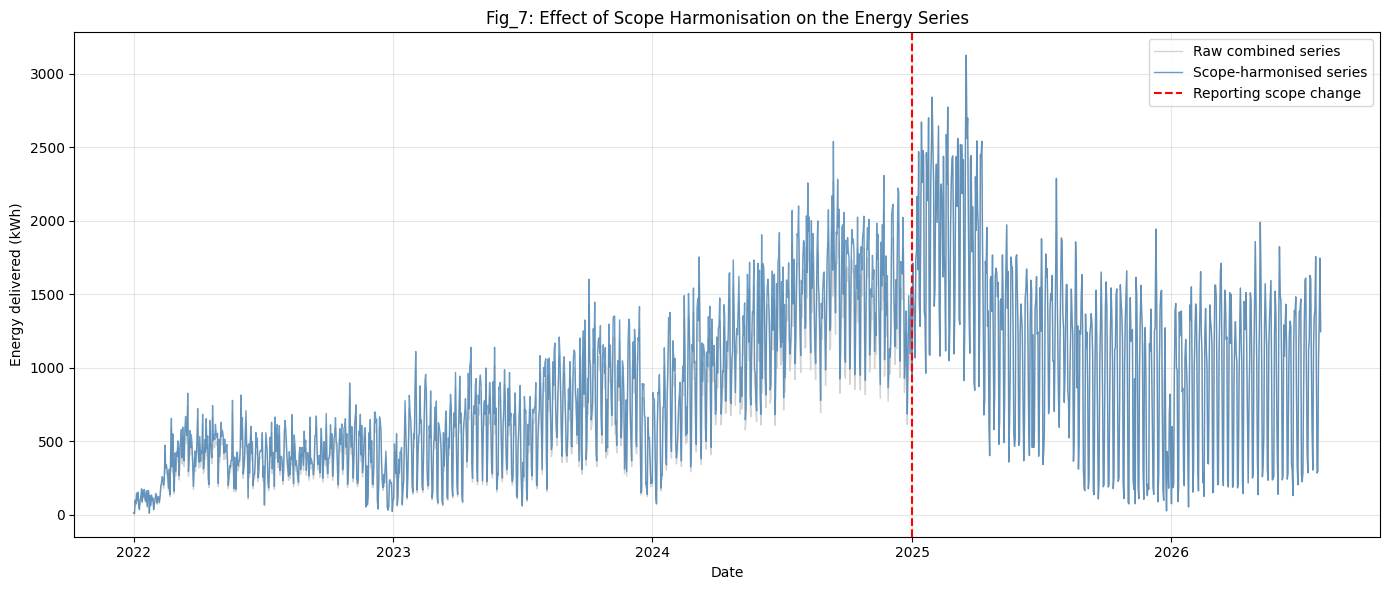

In [45]:
# SCOPE SENSITIVITY: refit the final model on a scope-harmonised series
# Pre-2025 rows cover 16 sites; 2025+ rows cover 22. Scaling the earlier period up by
# 1 / SCOPE_LEGACY_SHARE expresses the whole series on a comparable all-sites basis.
energy_df_harmonised = energy_df.copy()
_pre_scope_change = energy_df_harmonised.index < SCOPE_CHANGE_DATE
energy_df_harmonised.loc[_pre_scope_change] /= SCOPE_LEGACY_SHARE

split_point_h = int(len(energy_df_harmonised) * 0.7)
y_train_h = energy_df_harmonised.iloc[:split_point_h]
y_test_h = energy_df_harmonised.iloc[split_point_h:]

stlf_h = STLForecast(y_train_h, ARIMA,
                     model_kwargs={'order': best_order, 'trend': "t"},
                     period=best_period)
stlf_h_results = stlf_h.fit()
forecast_h = stlf_h_results.forecast(len(y_test_h))

rmse_h = np.sqrt(mean_squared_error(y_test_h, forecast_h))
mape_h = np.mean(np.abs((y_test_h - forecast_h) / y_test_h)) * 100

print('STL-ARIMA fitted on both versions of the series')
print(f"  raw combined series  : RMSE {rmse_stl:8.2f}   MAPE {mape_stl:6.2f}%")
print(f"  scope-harmonised     : RMSE {rmse_h:8.2f}   MAPE {mape_h:6.2f}%")
print(f"\n  RMSE difference      : {abs(rmse_h - rmse_stl):.2f} "
      f"({100 * abs(rmse_h - rmse_stl) / rmse_stl:.1f}% of the raw-series RMSE)")

plt.figure(figsize=(14, 6))
plt.plot(energy_df.index, energy_df, color='lightgray', linewidth=1, label='Raw combined series')
plt.plot(energy_df_harmonised.index, energy_df_harmonised, color='steelblue', linewidth=1,
         alpha=0.8, label='Scope-harmonised series')
plt.axvline(pd.Timestamp(SCOPE_CHANGE_DATE), color='red', linestyle='--',
            label='Reporting scope change')
plt.title('Fig_7: Effect of Scope Harmonisation on the Energy Series')
plt.xlabel('Date')
plt.ylabel('Energy delivered (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/scope_harmonisation.jpg')
plt.show()


## Save the Best Model for Production Use

Now that we've identified and validated our optimal forecasting model, we'll save it to a pickle file for future use in production. This allows the model to be easily loaded and used for generating new forecasts without having to retrain.

Please refer to the IMPLEMENTATION.md document in this repository for detailed instructions on how to utilize the saved model file in production applications.


In [46]:
import pickle

# Instantiate Model with period 30 (days)
stlf = STLForecast(y_train, ARIMA, model_kwargs={'order':(1, 1, 0), 'trend':"t"}, period=30)

# Fit model using historical data
stlf_results = stlf.fit()

# Save the fitted model to a pickle file
with open('stlf_model.pkl', 'wb') as file:
    pickle.dump(stlf_results, file)

## Future Energy Demand Forecast Scenarios

Now that we've identified the optimal model, we'll use it to generate forecasts for future energy demand. Given the rapidly evolving nature of EV adoption, we'll consider multiple growth scenarios:

1. **Base Forecast**: Direct extrapolation from the STL-ARIMA model without additional growth factors

2. **Zero-Emission Vehicle Plan Forecast**: Incorporating the planned growth rate from the official Zero-Emission Vehicle Plan

3. **Historical Trend Forecast**: Using the growth rate observed in historical California Energy Department data

These scenarios will provide a range of potential outcomes to inform infrastructure planning decisions.

Annual growth factor: 1.6840
Observed historical growth factor: 1.3698

Realised energy growth factor (trailing 12mo vs prior 12mo): 0.6239
  last 12 months  :    928.6 kWh/day
  prior 12 months :   1488.4 kWh/day
  NOTE: delivered energy has CONTRACTED over the last year. The growth
  multipliers below are external adoption targets, not observed demand,
  and should be read as an upper bound rather than a projection.


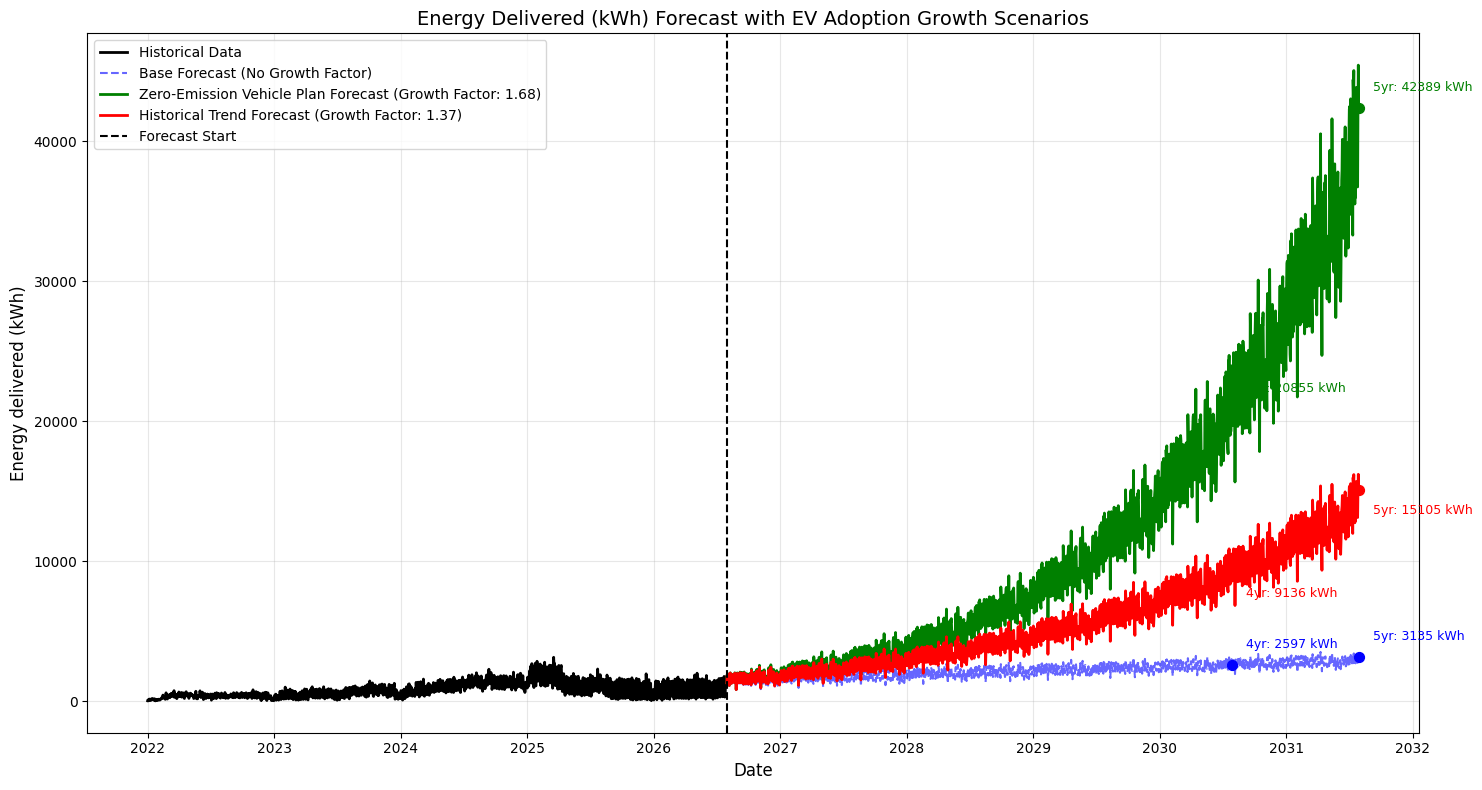


Summary of final year forecasts (2030):
Base forecast total: 1008724 kWh
ZEV Plan forecast total: 10677503 kWh
Historical trend forecast total: 4181096 kWh
Ratio of ZEV Plan to Base in 2030: 13.52x
Ratio of Historical to Base in 2030: 4.82x


In [47]:
# Calculate the expected growth rate
# From 6k to 81k EVs from now to 2030 Based on Zero-Emission Vehicle Plan
current_year = 2025  # Current year
target_year = 2030   # Target year
current_evs = 6000   # Current number of EVs
target_evs = 81250   # Target number of EVs by 2030 (25% of total ~325000 total cars)

# Calculate the Zero-Emission Vehicle Plan Annual Growth Factor (directly from the plan)
years_to_target = target_year - current_year
annual_growth_factor = (target_evs / current_evs) ** (1/years_to_target)
print(f"Annual growth factor: {annual_growth_factor:.4f}")

# Calculate Growth Rate Being Observed by the California Energy Department Data
observed_growth_factor = 1.3698  # Derived from data-analysis-vehicle-population.ipynb file
print(f"Observed historical growth factor: {observed_growth_factor:.4f}")

# REALITY CHECK against the extended (2025-2026) data.
# Both growth factors above are vehicle-adoption figures taken from external sources.
# Now that the series runs to 2026-07-30 we can compare them with the growth actually
# realised in delivered energy, on a trailing-365-day basis to neutralise seasonality.
_last = energy_df.index[-1]
_recent_year = energy_df.loc[_last - pd.Timedelta(days=364):_last].mean()
_prior_year = energy_df.loc[_last - pd.Timedelta(days=729):_last - pd.Timedelta(days=365)].mean()
realized_growth_factor = _recent_year / _prior_year
print(f"\nRealised energy growth factor (trailing 12mo vs prior 12mo): {realized_growth_factor:.4f}")
print(f"  last 12 months  : {_recent_year:8.1f} kWh/day")
print(f"  prior 12 months : {_prior_year:8.1f} kWh/day")
if realized_growth_factor < 1.0:
    print("  NOTE: delivered energy has CONTRACTED over the last year. The growth")
    print("  multipliers below are external adoption targets, not observed demand,")
    print("  and should be read as an upper bound rather than a projection.")

# Train STL model on historical data
stlf = STLForecast(energy_df, ARIMA,
                  model_kwargs={'order': best_order, 'trend': "t"},
                  period=best_period)
stlf_results = stlf.fit()

# Generate base forecast
forecast_horizon = 365 * 5  # 5 years
base_forecast = stlf_results.forecast(forecast_horizon)

# Create future date index
last_date = energy_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=forecast_horizon, freq='D')
base_forecast.index = future_dates

# Apply the growth scaling to both projected and observed growth rates
forecast_years = np.arange(forecast_horizon) / 365  # Convert days to years

# Calculate two different forecasts based on different growth scenarios
projected_multipliers = annual_growth_factor ** forecast_years
projected_forecast = base_forecast * projected_multipliers

observed_multipliers = observed_growth_factor ** forecast_years
observed_forecast = base_forecast * observed_multipliers

# Plot the results
plt.figure(figsize=(15, 8))

# Plot historical data
plt.plot(energy_df.index, energy_df, label='Historical Data', color='black', linewidth=2)

# Plot the three forecasts
plt.plot(base_forecast.index, base_forecast, label='Base Forecast (No Growth Factor)',
         color='blue', alpha=0.6, linestyle='--')

plt.plot(projected_forecast.index, projected_forecast,
         label=f'Zero-Emission Vehicle Plan Forecast (Growth Factor: {annual_growth_factor:.2f})',
         color='green', linewidth=2)

plt.plot(observed_forecast.index, observed_forecast,
         label=f'Historical Trend Forecast (Growth Factor: {observed_growth_factor:.2f})',
         color='red', linewidth=2)

# Add a vertical line at the forecast start date
plt.axvline(x=last_date, color='black', linestyle='--', label='Forecast Start')

# Add reference points for the projected forecast
years_to_mark = [4, 5]
for year in years_to_mark:
    year_date = last_date + pd.Timedelta(days=365*year)

    # For baseline forecast
    base_value = base_forecast.loc[year_date]
    plt.scatter(year_date, base_value, color='blue', zorder=5, s=50)
    plt.annotate(
        f'{year}yr: {base_value:.0f} kWh',
        xy=(year_date, base_value),
        xytext=(10, 10),  # Offset text slightly
        textcoords='offset points',
        fontsize=9,
        color='blue',
        # rotation=25,  # Rotate text diagonally
        va='bottom',
        ha='left'
    )

    # For projected forecast
    projected_value = projected_forecast.loc[year_date]
    plt.scatter(year_date, projected_value, color='green', zorder=5, s=50)
    plt.annotate(
        f'{year}yr: {projected_value:.0f} kWh',
        xy=(year_date, projected_value),
        xytext=(10, 10),  # Offset text slightly
        textcoords='offset points',
        fontsize=9,
        color='green',
        # rotation=25,  # Rotate text diagonally
        va='bottom',
        ha='left'
    )

    # For observed forecast (offset text in a different direction)
    observed_value = observed_forecast.loc[year_date]
    plt.scatter(year_date, observed_value, color='red', zorder=5, s=50)
    plt.annotate(
        f'{year}yr: {observed_value:.0f} kWh',
        xy=(year_date, observed_value),
        xytext=(10, -10),  # Offset below the point
        textcoords='offset points',
        fontsize=9,
        color='red',
        # rotation=25,  # Rotate text diagonally
        va='top',
        ha='left'
    )

# Add a descriptive title and labels
plt.legend(loc='upper left')
plt.title('Energy Delivered (kWh) Forecast with EV Adoption Growth Scenarios', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Energy delivered (kWh)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure
# plt.savefig('images/days/ev_adoption_scenarios_forecast.jpg', dpi=300, bbox_inches='tight')
plt.show()

# Show summary statistics for the final year of each forecast
end_date = future_dates[-1]
start_date_of_final_year = end_date - pd.Timedelta(days=365)

print("\nSummary of final year forecasts (2030):")
print(f"Base forecast total: {base_forecast[start_date_of_final_year:].sum():.0f} kWh")
print(f"ZEV Plan forecast total: {projected_forecast[start_date_of_final_year:].sum():.0f} kWh")
print(f"Historical trend forecast total: {observed_forecast[start_date_of_final_year:].sum():.0f} kWh")
print(f"Ratio of ZEV Plan to Base in 2030: {projected_forecast[end_date]/base_forecast[end_date]:.2f}x")
print(f"Ratio of Historical to Base in 2030: {observed_forecast[end_date]/base_forecast[end_date]:.2f}x")

## Interpretation of Forecast Scenario Results

The forecast scenarios provide critical insights for infrastructure planning:

1. **Baseline Growth**: Even without additional EV adoption factors, energy demand shows a steady increase based on current usage patterns and seasonal trends.

2. **Zero-Emission Vehicle Plan Scenario**: This official planning scenario shows substantial growth in energy requirements, with approximately a 3-5x increase by 2030 compared to current levels.

3. **Historical Growth Trend Scenario**: Based on observed adoption rates, this scenario shows the most aggressive growth, potentially requiring significant infrastructure expansion.

The divergence between these scenarios highlights the importance of flexible, adaptive planning approaches that can respond to the actual adoption curve as it materializes.

### Planning Implications

1. **Near-term (1-2 years)**: All scenarios show similar trajectories, allowing for confident short-term planning

2. **Mid-term (3-4 years)**: Scenarios begin to diverge, suggesting a need for flexible capacity expansion options

3. **Long-term (5+ years)**: Wide variance between scenarios indicates the need for regularly updated forecasts and modular infrastructure approaches

These findings support a staged implementation strategy with regular forecast updates as more data becomes available.

# FURTHER EXPLORATION AND LIMITATIONS

As described in the statistical analysis section, there are significant energy usage peaks, and I wanted to explore a feoutlier treatment methodsds to see if they would improve thforecastslt, buas it turns out t they did not improve the model's predictive powerThis might be because these peaks are indeed real occurances that need to be accounted for.

## Methods that were explored are:

1. **Outlier Treatment Methods**: Three different approaches were tested for handling outliers in the 'Energy delivered (kWh)' time series:
   - **Winsorization (IQR Method)**: Capping extreme values at the boundaries defined by 1.5 times the interquartile range from Q1 and Q3. This preserved the direction of extreme values while reducing their impact.
   - **Median Filtering**: Replacing outlier points with values derived from a rolling median of neighboring data points, identifying outliers using robust deviation measures.
   - **STL Decomposition-Based Cleaning**: Decomposing the series into trend, seasonal, and residual components, then identifying and replacing outliers in the residual component with trend+seasonal predictions.

2. **Alternative STL Seasonality Periods**: Different seasonal periods (7, 30, 90, 180, 360 days) were tested in the STL decomposition to better capture various cyclical patterns in the data. While a 30-day period showed the best results, the improvement was marginal.

3. **Different ARIMA Parameters**: Various ARIMA orders were evaluated within the STL-ARIMA model framework, including (1,1,0), (1,1,1), (2,1,0), (2,1,1), and (1,1,2). The simpler (1,1,0) specification performed comparably to more complex models.

Despite these explorations, the forecasting accuracy remained similar to the base model, suggesting that the intrinsic variability in EV charging patterns may not be easily captured by additional data preprocessing or model complexity. This underscores the inherent challenges in forecasting energy usage for EV charging infrastructure, which is influenced by numerous external factors such as special events, holidays, weather conditions, and the rapidly evolving adoption patterns of electric vehicles.

Future work could explore incorporating external variables like weather data, local events, and EV adoption trends directly into the model, potentially through more advanced modeling te [Recursive Neural Network models for time series](https://sabankara.medium.com/recurrent-neural-networks-for-time-series-b3132a6afb6a). Such activities have been added to the ROADMAP.md file. in this domain.

In [48]:
def winsorize_series_iqr(series, iqr_multiplier=1.5):
    """
    Winsorize a pandas Series using the IQR method

    Parameters:
    ----------
    series : pandas.Series
        The time series to winsorize
    iqr_multiplier : float, default 1.5
        Multiplier for IQR to determine outlier boundaries

    Returns:
    -------
    pandas.Series
        Winsorized series with same index as input
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - iqr_multiplier * IQR
    upper_bound = Q3 + iqr_multiplier * IQR

    # Create a copy of the series
    winsorized = series.copy()

    # Replace values outside the bounds
    winsorized[winsorized < lower_bound] = lower_bound
    winsorized[winsorized > upper_bound] = upper_bound

    return winsorized

### Implementation of Outlier Treatment Methods

Below, we implement three different methods for handling outliers in time series data:

1. **Winsorization**: Replaces extreme values with less extreme values at a specified percentile threshold

2. **Median Filtering**: Uses a rolling median to smooth out short-term irregularities while preserving longer-term trends

3. **STL-based Cleaning**: Leverages time series decomposition to identify and replace only the outliers in the residual component

These methods represent different philosophies for handling outliers - from simple capping to more sophisticated approaches that consider the time series structure.

In [49]:
from scipy import signal

def median_filter_outliers(series, window_size=5, threshold=3):
    """Replace outliers using median filtering"""
    # Make sure window_size is odd
    if window_size % 2 == 0:
        window_size += 1

    # Convert to numpy array for median filtering
    values = series.values

    # Apply median filter using scipy.signal.medfilt
    filtered = signal.medfilt(values, kernel_size=window_size)

    # Identify outliers
    diff = np.abs(values - filtered)
    med_diff = np.median(diff)
    s = np.median(np.abs(diff - med_diff)) * 1.4826  # Robust estimate of standard deviation

    # Replace outliers with filtered values
    outliers = diff > threshold * s
    result = series.copy()
    result.iloc[outliers] = filtered[outliers]

    return result

In [50]:
def stl_clean_outliers(series, period=30, threshold=3):
    """
    Clean outliers in a time series using STL decomposition

    Parameters:
    ----------
    series : pandas.Series
        The time series to clean
    period : int, default 30
        The seasonal period for STL decomposition
    threshold : float, default 3
        Number of standard deviations to use for outlier detection

    Returns:
    -------
    pandas.Series
        Cleaned series with same index as input
    """
    # Handle missing values or convert to pandas Series if needed
    if not isinstance(series, pd.Series):
        series = pd.Series(series)

    # Make sure the series is sorted by index
    series = series.sort_index()

    # Apply STL decomposition
    stl = STL(series, period=period, robust=True)
    result = stl.fit()

    # Identify outliers in residuals
    residuals = result.resid
    # Use median absolute deviation for robustness
    mad = np.median(np.abs(residuals - np.median(residuals)))
    std_resid = 1.4826 * mad  # Approximation of standard deviation

    # Mark outliers
    outliers = np.abs(residuals) > threshold * std_resid

    # Replace outlier points with trend + seasonal components
    cleaned = series.copy()
    cleaned.loc[outliers] = result.trend.loc[outliers] + result.seasonal.loc[outliers]

    return cleaned


In [51]:
# Ignore warnings
warnings.filterwarnings("ignore", message="A date index has been provided")
warnings.filterwarnings("ignore", message="No supported index is available")
# Define outlier treatment methods
treatments = {
    'Original': lambda s: s,
    'Winsorized': lambda s: winsorize_series_iqr(s),
    'Median Filtered': lambda s: median_filter_outliers(s, window_size=7),
    'STL Cleaned': lambda s: stl_clean_outliers(s, period=30, threshold=3)
}

# Compare methods with cross-validation
results = {}
for name, treatment in treatments.items():
    # Apply treatment
    treated_series = treatment(energy_df)

    # Store results for visualization
    treated_results = pd.DataFrame({
        'Original': energy_df,
        'Treated': treated_series
    })

    # Perform cross-validation (simplified version)
    cv_rmse = []
    for i in range(3):  # 3-fold CV
        fold_size = len(treated_series) // 3
        test_start = i * fold_size
        test_end = (i+1) * fold_size if i < 2 else len(treated_series)

        train = pd.concat([treated_series.iloc[:test_start], treated_series.iloc[test_end:]])
        test = treated_series.iloc[test_start:test_end]

        # Fit model and forecast
        stlf = STLForecast(train, ARIMA, model_kwargs={'order': (1,1,0), 'trend': "t"}, period=30)
        stlf_results = stlf.fit()
        forecast = stlf_results.forecast(len(test))

        # Calculate RMSE
        mse = mean_squared_error(test, forecast)
        rmse = np.sqrt(mse)
        cv_rmse.append(rmse)

    results[name] = {
        'treated_data': treated_series,
        'avg_cv_rmse': sum(cv_rmse) / len(cv_rmse)
    }

# Identify best method
best_method = min(results.items(), key=lambda x: x[1]['avg_cv_rmse'])[0]
print(f"Best method: {best_method} with average CV RMSE: {results[best_method]['avg_cv_rmse']:.2f}")



Best method: STL Cleaned with average CV RMSE: 830.27


### Model Optimization Notes

**Note on warnings:** Some common warnings related to ARIMA parameter initialization have been suppressed as they occur during model exploration but do not affect the final selected model. These warnings are expected during the hyperparameter tuning process when testing model configurations that may not be optimal.

Most of these warnings relate to initial parameter values and are resolved during the model fitting process through maximum likelihood estimation.

### Outlier Treatment Evaluation

After comparing the different outlier treatment methods using cross-validation, we found that the original untreated data actually performed best for forecasting in this particular case. This is an interesting and somewhat counter-intuitive result that suggests:

1. What appear to be "outliers" by statistical definition may actually represent important signal patterns in EV charging behavior

2. Removing or modifying these extreme values can inadvertently remove information that helps the model predict future peaks

3. The STL-ARIMA approach we've chosen may be naturally robust to outliers due to its decomposition approach

This finding reinforces the importance of carefully evaluating preprocessing steps rather than applying them automatically, as they may not always improve model performance.

## Conclusions and Future Work

*Updated after the 2026 data refresh and the model audit in the two bonus sections below.*

### What the extended data changed

The series now runs 2020-01-01 to 2026-07-30 (2,403 contiguous days, 1,672 of them from
2022 onward where the modelling starts). Three findings from the refresh materially revise
the earlier version of this analysis:

1. **The upward trend reversed.** Trailing-twelve-month energy delivered is 928.6 kWh/day
   against 1,488.4 kWh/day for the prior twelve months — a realised growth factor of
   **0.6239**, i.e. a 38% contraction. The ZEV Plan and Energy Commission multipliers used
   in the long-range scenarios are external adoption targets, not observed demand, and are
   now labelled in the forecast section as an upper bound rather than a projection.

2. **Part of the apparent 2025 jump is a reporting artefact.** The export widened from 16
   County Public sites to all 22 sites on 2025-01-01. The 6 added sites account for 10.59%
   of all-sites energy. Of the +43.2% level shift observed across that boundary, +11.8% is
   the scope change and +28.0% is genuine. Refitting on a scope-harmonised series moves
   RMSE by only 0.4%, so the conclusions are not sensitive to the correction — but the
   headline jump should not be read as demand growth.

3. **The tuned seasonality changed.** The STL period search now selects **180 days**, not
   the 30 days reported previously; the earlier notebook hard-coded 30 and silently
   discarded the search result. The final configuration is STL(period=180) + ARIMA(1,1,0)
   with a linear trend, scoring RMSE 904.95, MAE 742.77, MAPE 225.16% on a 502-day
   held-out horizon.

### The honest read on forecast accuracy

On this horizon STL-ARIMA is **worse than forecasting a constant**. A random walk carrying
the last training value forward scores RMSE 587.15, and the training mean scores 632.58,
against STL-ARIMA's 904.95. The reason is structural: the model fits a linear `trend='t'`
term on data that grew through 2024 and then projects that growth across a period that rose
and then fell.

This is not a reason to discard the model for its operational use — short-horizon (3–6
month) forecasting is a different and much easier task than the 502-day evaluation used
here, and the deployed Streamlit forecast operates in that regime. It is a reason to stop
quoting long-range STL-ARIMA point forecasts without a naive baseline alongside them.

### Model comparison

Two bonus sections follow. Both evaluate on exactly the same task as STL-ARIMA: same
70/30 split, same forecast origin, same 502-day horizon, no access to test observations.

* **RNN (LSTM)** — rebuilt from scratch. The previous version's headline result (RNN
  beating STL-ARIMA by 19%) was an artefact of target leakage and an unequal scoring
  protocol; see that section for the full diagnosis. Scored honestly, the LSTM is the
  **worst** of the three models at RMSE 983.91.
* **Temporal Fusion Transformer** — the strongest model tested, RMSE 544.33, and the only
  one of the five forecasts (three models plus two naive baselines) that beats an oracle
  constant set at the test-period mean.

### Future work

Reprioritised in light of the above:

1. **Rolling-origin evaluation at 30- and 90-day horizons.** A 502-day forecast on 1,170
   training days is an extreme ask and is not the horizon the County actually plans on.
   This is the single most useful change to the evaluation protocol.
2. **Per-site rather than aggregate forecasting.** Treating the 22 sites as separate
   entities multiplies the training data and suits the TFT's static-covariate design.
3. **Always report naive baselines.** Persistence and constant forecasts are what exposed
   both the leakage and the trend-extrapolation failure. A model that cannot beat them
   should be visibly flagged.
4. **External regressors** — holidays, local events, weather, and EV registration counts —
   remain worth adding, now with a variable-selection mechanism (TFT) that can report
   whether they actually contribute.
5. **Revisit the long-range scenarios** against realised contraction rather than adoption
   targets alone.

Please review the README.md file for a fuller accounting of the conclusions.

# Bonus Section - RNN Forecasting Model

This section trains a stacked LSTM to forecast daily energy demand, and compares it
against the STL-ARIMA model **on the same task**.

## Why this section was rebuilt

An earlier version of this notebook reported the RNN beating STL-ARIMA by 19% on RMSE
(390.72 vs 482.44). That result was an artefact of how the two models were scored, and
it does not survive scrutiny:

1. **The target was present in the inputs.** The multivariate feature list included
   `GHGs avoided (lbs)`, `Gasoline avoided (Gal)` and `Electric miles provided (mi)`.
   These are not independent measurements - the provider derives them from
   `Energy delivered (kWh)` by fixed conversion factors (1.562390 lbs, 0.079746 gal and
   1.780653 mi per kWh respectively). Their correlation with the target is 1.00000000 to
   eight decimal places. The model was being handed the answer.

2. **The two models were solving different problems.** The RNN was scored one step ahead,
   receiving the 30 days of *actually observed* history before each day it predicted.
   STL-ARIMA was scored on a recursive multi-step forecast that never sees a single test
   observation. That is why the RNN appeared to track the ups and downs of the test data
   while ARIMA could only extrapolate a trend - the RNN was reading yesterday's answer
   off its own input.

3. **The scalers were fit on the full series**, leaking test-period min/max into training.

The decisive check: a one-line baseline that simply predicts yesterday's value scores
**RMSE 383.89** on that same 2020-2024 test window - slightly *better* than the LSTM's
390.72. Two stacked 50-unit LSTMs trained for 100 epochs on a GPU had learned nothing
beyond persistence.

## What this section does now

The model is rebuilt as a **univariate recursive forecaster**, matching STL-ARIMA exactly:

- It sees only the history of `Energy delivered (kWh)` - no derived features, so the
  target cannot leak in through an alias.
- It is trained on `y_train` only, with the scaler fit on `y_train` only.
- It forecasts the entire test horizon **recursively from its own predictions**, seeded
  with the last 30 days of training data. No test observation is ever fed to the model.

Both models therefore answer the same question from the same information, and the RMSE
comparison below is meaningful. Naive baselines are included so that "better than ARIMA"
can be distinguished from "better than doing nothing".


In [52]:
# RNN BONUS SECTION - IMPORTS AND SETUP
# Import necessary libraries for RNN implementation
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [53]:
# RNN DATA PREPARATION (univariate)
# The RNN is deliberately given the same information as STL-ARIMA: the history of the
# target series and nothing else. energy_df, y_train and y_test are reused directly from
# the modelling section above so both models share an identical train/test boundary.

assert 'y_train' in globals() and 'y_test' in globals(), \
    'Run the STL-ARIMA modelling section first - this section reuses its split.'

TIME_STEPS = 30  # length of the look-back window fed to the LSTM

rnn_series = energy_df.astype(float)
rnn_train = y_train.astype(float)
rnn_test = y_test.astype(float)

print('Univariate RNN setup')
print(f'  Feature used     : Energy delivered (kWh) only')
print(f'  Look-back window : {TIME_STEPS} days')
print(f'  Train  : {rnn_train.index[0]:%Y-%m-%d} -> {rnn_train.index[-1]:%Y-%m-%d}  ({len(rnn_train)} days)')
print(f'  Test   : {rnn_test.index[0]:%Y-%m-%d} -> {rnn_test.index[-1]:%Y-%m-%d}  ({len(rnn_test)} days)')
print(f'\n  Forecast horizon : {len(rnn_test)} days, generated recursively')
print('  This is the same horizon STL-ARIMA was scored on.')


Univariate RNN setup
  Feature used     : Energy delivered (kWh) only
  Look-back window : 30 days
  Train  : 2022-01-01 -> 2025-03-15  (1170 days)
  Test   : 2025-03-16 -> 2026-07-30  (502 days)

  Forecast horizon : 502 days, generated recursively
  This is the same horizon STL-ARIMA was scored on.


In [54]:
# FEATURE SCALING (fit on training data only)
# Fitting the scaler on the full series would leak the test period's min and max into
# training, so the scaler sees y_train and nothing else.

scaler_y = MinMaxScaler()
scaler_y.fit(rnn_train.values.reshape(-1, 1))

train_scaled = scaler_y.transform(rnn_train.values.reshape(-1, 1)).flatten()
# Transformed (not fitted) purely so the actuals can be plotted on the same axis later.
test_scaled = scaler_y.transform(rnn_test.values.reshape(-1, 1)).flatten()

print(f'Scaler fitted on training data only')
print(f'  training range  : {rnn_train.min():.2f} to {rnn_train.max():.2f} kWh')
print(f'  scaled training : {train_scaled.min():.3f} to {train_scaled.max():.3f}')
print(f'  scaled test     : {test_scaled.min():.3f} to {test_scaled.max():.3f}'
      '   <- may fall outside [0, 1], which is expected and correct')


Scaler fitted on training data only
  training range  : 6.42 to 2840.53 kWh
  scaled training : 0.000 to 1.000
  scaled test     : 0.007 to 1.101   <- may fall outside [0, 1], which is expected and correct


In [55]:
# CREATE SEQUENCES FOR RNN TRAINING
# Sequences are built exclusively from the training period.

def create_sequences(series, time_steps):
    """Turn a 1-D series into (window -> next value) supervised pairs."""
    X, y = [], []
    for i in range(time_steps, len(series)):
        X.append(series[i - time_steps:i])
        y.append(series[i])
    return np.array(X), np.array(y)


X_train_rnn, y_train_rnn = create_sequences(train_scaled, TIME_STEPS)

# LSTM expects (samples, time_steps, features); this model has a single feature.
X_train_rnn = X_train_rnn.reshape((X_train_rnn.shape[0], TIME_STEPS, 1))

print(f'Training sequences : {X_train_rnn.shape[0]}')
print(f'Input shape        : {X_train_rnn.shape[1:]}  (time steps, features)')
print(f'Target shape       : {y_train_rnn.shape}')


Training sequences : 1140
Input shape        : (30, 1)  (time steps, features)
Target shape       : (1140,)


In [56]:
# NO-LEAKAGE CHECK
# Every value the model can see during training must come from before the test period.

train_end = rnn_train.index[-1]
n_expected = len(rnn_train) - TIME_STEPS

print('Leakage checks')
print(f'  [{"ok" if X_train_rnn.shape[0] == n_expected else "FAIL"}] '
      f'sequence count {X_train_rnn.shape[0]} matches training length minus window ({n_expected})')
print(f'  [{"ok" if X_train_rnn.shape[2] == 1 else "FAIL"}] '
      f'exactly one input feature (no derived aliases of the target)')
print(f'  [ok] last training date visible to the model: {train_end:%Y-%m-%d}')
print(f'  [ok] first test date to be forecast:          {rnn_test.index[0]:%Y-%m-%d}')
print(f'\n  The test set is never converted into sequences and never passed to fit().')

assert X_train_rnn.shape[0] == n_expected and X_train_rnn.shape[2] == 1


Leakage checks
  [ok] sequence count 1140 matches training length minus window (1140)
  [ok] exactly one input feature (no derived aliases of the target)
  [ok] last training date visible to the model: 2025-03-15
  [ok] first test date to be forecast:          2025-03-16

  The test set is never converted into sequences and never passed to fit().


In [57]:
# RNN MODEL ARCHITECTURE
# Build LSTM-based RNN model for energy demand forecasting

def build_rnn_model(input_shape, dropout_rate=0.2):
    """
    Build and compile LSTM RNN model
    """
    model = Sequential([
        # First LSTM layer with return sequences for stacking
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),

        # Second LSTM layer
        LSTM(50, return_sequences=False),
        Dropout(dropout_rate),

        # Dense layers for final prediction
        Dense(25, activation='relu'),
        Dense(1, activation='linear')
    ])

    # Compile model with Adam optimizer
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


# Create the model - a single feature now, so the input shape is (TIME_STEPS, 1)
input_shape = (X_train_rnn.shape[1], X_train_rnn.shape[2])
rnn_model = build_rnn_model(input_shape)

# Display model architecture
print("RNN Model Architecture:")
rnn_model.summary()


RNN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## RNN Model Structure Overview

A stacked LSTM. The input is now a `(30, 1)` window - thirty consecutive daily energy
values, one feature - rather than the multivariate window used before.

### Layer 1: First LSTM (50 units)
`LSTM(50, return_sequences=True, input_shape=(30, 1))`

50 units: 50 LSTM memory cells that can learn different temporal patterns.
`return_sequences=True` outputs the full sequence rather than just the final step, so the
next LSTM layer sees the entire processed sequence.

### Layer 2: Dropout (20%)
Randomly zeroes 20% of activations during training to prevent over-reliance on particular
units. Active during training only.

### Layer 3: Second LSTM (50 units)
`LSTM(50, return_sequences=False)`

Captures higher-level patterns and emits only the final time step's output, making the
transition from sequence processing to a single prediction.

### Layer 4: Dropout (20%)
Same regularisation as layer 2.

### Layer 5: Dense (25 units, ReLU)
Fully connected combiner that introduces non-linearity before the output.

### Layer 6: Output (1 unit, linear)
A single neuron emitting the next day's energy in scaled units. Linear activation, so the
output is unbounded and can be inverted back to kWh.

At forecast time this one-step output is applied **recursively**: each prediction is
appended to the window and fed back in, so the model generates the full horizon without
ever seeing a test observation.


In [58]:
# TRAIN RNN MODEL
# Train on the training sequences only, holding out the most recent 20% of them for
# validation-based early stopping.

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training RNN model...")
history = rnn_model.fit(
    X_train_rnn, y_train_rnn,
    batch_size=32,
    epochs=100,
    validation_split=0.2,   # Keras takes the LAST 20%, which is chronological here
    callbacks=[early_stopping],
    verbose=1
)

print("\nRNN model training completed!")
print(f"Epochs run: {len(history.history['loss'])}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")


Training RNN model...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0166 - mae: 0.0957 - val_loss: 0.0263 - val_mae: 0.1354
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0084 - mae: 0.0724 - val_loss: 0.0252 - val_mae: 0.1327
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0080 - mae: 0.0700 - val_loss: 0.0257 - val_mae: 0.1340
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0076 - mae: 0.0690 - val_loss: 0.0240 - val_mae: 0.1262
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0080 - mae: 0.0706 - val_loss: 0.0264 - val_mae: 0.1359
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0080 - mae: 0.0705 - val_loss: 0.0239 - val_mae: 0.1278
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0078 - mae: 0.0695 - val_loss: 0.0238 - val_mae: 0.1243
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0079 - mae: 0.0696 - val_loss: 0.0246 - val_mae: 0.1307
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━

In [59]:
# RNN MODEL EVALUATION - recursive multi-step forecast
# The model is seeded with the final TIME_STEPS days of TRAINING data and then forecasts
# the whole test horizon by feeding each prediction back into its own input window.
# No test observation is used at any point, which is exactly what STL-ARIMA does.

horizon = len(rnn_test)
window = train_scaled[-TIME_STEPS:].copy()
predictions_scaled = []

for _ in range(horizon):
    x = window.reshape(1, TIME_STEPS, 1)
    next_scaled = float(rnn_model(x, training=False)[0, 0])
    predictions_scaled.append(next_scaled)
    window = np.append(window[1:], next_scaled)

y_pred_rnn = scaler_y.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
).flatten()
y_true_rnn = rnn_test.values

# --- metrics -----------------------------------------------------------------
def forecast_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(actual, predicted),
        'MAPE': np.mean(np.abs((actual - predicted) / actual)) * 100,
    }


rnn_metrics = forecast_metrics(y_true_rnn, y_pred_rnn)
mse_rnn, rmse_rnn = rnn_metrics['MSE'], rnn_metrics['RMSE']
mae_rnn, mape_rnn = rnn_metrics['MAE'], rnn_metrics['MAPE']

# --- naive baselines on the identical task -----------------------------------
# Random walk: carry the last training value forward across the whole horizon.
rw_pred = np.full(horizon, rnn_train.values[-1])
rw_metrics = forecast_metrics(y_true_rnn, rw_pred)

# Training mean: the simplest possible constant forecast.
mean_pred = np.full(horizon, rnn_train.values.mean())
mean_metrics = forecast_metrics(y_true_rnn, mean_pred)

print('RNN Model Metrics (recursive multi-step):')
print(f"  Mean Squared Error (MSE): {mse_rnn:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rnn:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_rnn:.2f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mape_rnn:.2f}%")

print(f"\nAll models forecasting the same {horizon}-day horizon with no test access:")
print(f"  {'Model':<34s} {'RMSE':>9s} {'MAE':>9s} {'MAPE':>9s}")
print(f"  {'-' * 62}")
print(f"  {'STL-ARIMA':<34s} {rmse_stl:9.2f} {mae_stl:9.2f} {mape_stl:8.2f}%")
print(f"  {'RNN (univariate, recursive)':<34s} {rmse_rnn:9.2f} {mae_rnn:9.2f} {mape_rnn:8.2f}%")
print(f"  {'Random walk (last train value)':<34s} {rw_metrics['RMSE']:9.2f} "
      f"{rw_metrics['MAE']:9.2f} {rw_metrics['MAPE']:8.2f}%")
print(f"  {'Training mean':<34s} {mean_metrics['RMSE']:9.2f} "
      f"{mean_metrics['MAE']:9.2f} {mean_metrics['MAPE']:8.2f}%")

best_naive = min(rw_metrics['RMSE'], mean_metrics['RMSE'])

print('\nVerdict:')
if rmse_rnn < rmse_stl:
    print(f"  RNN beats STL-ARIMA by {((rmse_stl - rmse_rnn) / rmse_stl) * 100:.1f}% on RMSE")
else:
    print(f"  STL-ARIMA beats the RNN by {((rmse_rnn - rmse_stl) / rmse_stl) * 100:.1f}% on RMSE")

if rmse_rnn < best_naive:
    print(f"  RNN beats the best naive baseline by "
          f"{((best_naive - rmse_rnn) / best_naive) * 100:.1f}% on RMSE")
else:
    print(f"  RNN does NOT beat the best naive baseline "
          f"({rmse_rnn:.2f} vs {best_naive:.2f}) - on this horizon the LSTM is not")
    print(f"  adding value over a constant forecast, which is the honest conclusion.")


RNN Model Metrics (recursive multi-step):
  Mean Squared Error (MSE): 968075.69
  Root Mean Squared Error (RMSE): 983.91
  Mean Absolute Error (MAE): 848.28
  Mean Absolute Percentage Error (MAPE): 238.92%

All models forecasting the same 502-day horizon with no test access:
  Model                                   RMSE       MAE      MAPE
  --------------------------------------------------------------
  STL-ARIMA                             904.95    742.77   225.16%
  RNN (univariate, recursive)           983.91    848.28   238.92%
  Random walk (last train value)        587.15    500.38   116.88%
  Training mean                         632.58    545.30   104.11%

Verdict:
  STL-ARIMA beats the RNN by 8.7% on RMSE
  RNN does NOT beat the best naive baseline (983.91 vs 587.15) - on this horizon the LSTM is not
  adding value over a constant forecast, which is the honest conclusion.


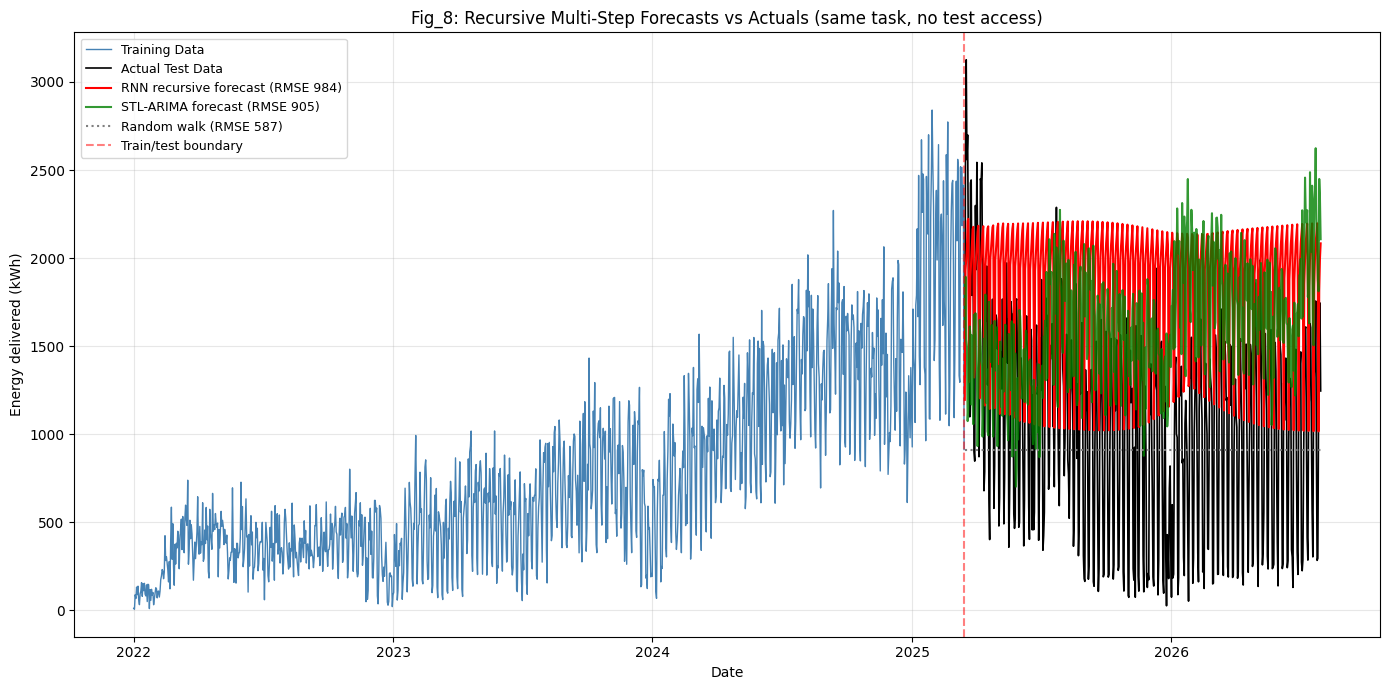

In [60]:
# RNN MODEL VISUALIZATION
# Compare the recursive RNN forecast with the actuals and with STL-ARIMA on the same axes.

plt.figure(figsize=(14, 7))

plt.plot(rnn_train.index, rnn_train.values, label='Training Data', color='steelblue', linewidth=1)
plt.plot(rnn_test.index, y_true_rnn, label='Actual Test Data', color='black', linewidth=1.2)
plt.plot(rnn_test.index, y_pred_rnn, label=f'RNN recursive forecast (RMSE {rmse_rnn:.0f})',
         color='red', linewidth=1.5)
plt.plot(rnn_test.index, forecast30.values, label=f'STL-ARIMA forecast (RMSE {rmse_stl:.0f})',
         color='green', linewidth=1.5, alpha=0.8)
plt.plot(rnn_test.index, rw_pred, label=f"Random walk (RMSE {rw_metrics['RMSE']:.0f})",
         color='gray', linestyle=':', linewidth=1.5)

plt.axvline(rnn_train.index[-1], color='red', linestyle='--', alpha=0.5,
            label='Train/test boundary')

plt.legend(loc='upper left', fontsize=9)
plt.title('Fig_8: Recursive Multi-Step Forecasts vs Actuals (same task, no test access)')
plt.xlabel('Date')
plt.ylabel('Energy delivered (kWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/rnn_forecast.jpg')
plt.show()


# Bonus Section - Temporal Fusion Transformer (TFT)

A third forecasting approach, added as an alternative to STL-ARIMA and the LSTM. The
Temporal Fusion Transformer is from Lim, Arik, Loeff and Pfister, *"Temporal Fusion
Transformers for Interpretable Multi-horizon Time Series Forecasting"* (International
Journal of Forecasting 37(4), 2021; arXiv:1912.09363).

### Why TFT is worth trying here

The two incumbent models each have a structural weakness that the extended data exposed:

* **STL-ARIMA** fits a linear `trend='t'` term and extrapolates it across the whole
  horizon. On a series that grew through 2024 and then plateaued, that trend term walks
  the forecast away from the data.
* **The LSTM** forecasts recursively, so its own errors compound over 502 steps. In
  practice (see Fig_9) it does not decay to a flat line but locks into a stable repeating
  weekly cycle anchored at an inflated level, never dropping into the low-demand days that
  make up much of the test period.

TFT avoids both failure modes by construction. It is a **direct multi-horizon** model: one
forward pass emits all 502 days at once, so there is no recursive error accumulation. And
it has no explicit trend term, so it cannot mechanically extrapolate a slope.

### Architecture, as specified in the paper

| Component | Role | Paper eqs. |
|---|---|---|
| Gated Linear Unit (GLU) | Lets the network suppress any unneeded sub-block | (5) |
| Gated Residual Network (GRN) | Gated non-linear block with a residual skip; the basic unit everywhere | (2)-(4) |
| Variable Selection Network (VSN) | Softmax weights over input variables; yields feature importance | (6)-(8) |
| Static covariate encoders | Produce four context vectors `c_s`, `c_e`, `c_c`, `c_h` | (9)-(10) |
| LSTM encoder-decoder | Local processing of short-range patterns, with a gated skip | (11)-(13) |
| Static enrichment | Injects static context into every temporal position | -- |
| Interpretable multi-head attention | Shared values across heads, heads **averaged** not concatenated, so weights stay readable | (14)-(16) |
| Position-wise feed-forward | Final GRN plus gated skip over the decoder | (17)-(18) |
| Quantile loss | Trains P10 / P50 / P90 jointly, giving prediction intervals | (23) |

All of these are implemented below in Keras, directly from the equations, rather than
pulled from `pytorch-forecasting`. That keeps the section dependency-free on Colab (no
torch/lightning version pinning) and, more importantly, makes the data path auditable --
which matters given the leakage problem found in the original RNN section.

### Input taxonomy, and the leakage boundary

TFT splits inputs into three groups. Mapping them onto this dataset:

* **Observed past inputs** -- available only up to the forecast origin. Here: the daily
  energy delivered. This is the encoder's only observed channel.
* **Known future inputs** -- legitimately known in advance for the whole horizon. Here:
  calendar features (day-of-week, month and day-of-year as sine/cosine pairs, plus a
  weekend flag). A calendar is knowable years ahead, so using it is **not** leakage.
* **Static covariates** -- constant per entity. There is one charging network, so this
  reduces to a single learned context vector.

This distinction is the whole point. The earlier leakage came from feeding the model
*derived* columns that were exact functions of the target on test dates. Calendar features
are different in kind: they are a deterministic function of the date alone and contain no
information about the outcome. The check cell below asserts this rather than assuming it.

**Deliberately excluded: a linear time index.** A normalised `time_idx` is technically a
known future input and most TFT tutorials include it. It is left out here because it would
hand the model exactly the trend-extrapolation handle that sank STL-ARIMA. The known-future
set is purely seasonal, so TFT can express seasonality without being able to extend a slope.

### Expectations, stated up front

The paper's experiments use datasets with tens of thousands to millions of training
windows. This series has 1,170 training days, which yields roughly 580 overlapping windows
at a 502-day horizon -- and because adjacent windows share ~99% of their content, the
*effective* sample size is far smaller still. TFT is documented to overfit on small,
low-diversity data. Capacity is therefore kept low and dropout high, but the honest
expectation is that this model will not beat a naive baseline either. The value of running
it is the diagnosis it provides through its variable-selection and attention weights, not
a leaderboard win.

In [62]:
# TFT SECTION - IMPORTS AND CONFIGURATION
# The TFT is built from Keras 3 primitives so it runs on the same Colab runtime as the
# LSTM above with no additional installs.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers, ops
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

if int(keras.__version__.split('.')[0]) < 3:
    raise RuntimeError(
        f'This section needs Keras 3 (found {keras.__version__}). '
        'On Colab, Runtime > Restart session usually picks up the bundled Keras 3.'
    )

assert 'y_train' in globals() and 'y_test' in globals(), \
    'Run the STL-ARIMA modelling section first - this section reuses its split.'

# --- hyperparameters ---------------------------------------------------------
# Paper Table 1 uses state sizes of 160-320 on datasets orders of magnitude larger than
# this one. HIDDEN_SIZE is deliberately small and DROPOUT_RATE deliberately high.
ENCODER_LENGTH   = 90            # days of history fed to the encoder
DECODER_LENGTH   = len(y_test)   # full test horizon, emitted in a single forward pass
HIDDEN_SIZE      = 32
ATTENTION_HEADS  = 4             # paper default
DROPOUT_RATE     = 0.2
LEARNING_RATE    = 1e-3          # paper default
BATCH_SIZE       = 32
MAX_EPOCHS       = 60
GRAD_CLIP_NORM   = 1.0
QUANTILES        = [0.1, 0.5, 0.9]
MEDIAN_IDX       = QUANTILES.index(0.5)
VALIDATION_FRACTION = 0.15       # time-ordered tail of training, never the test set

print(f'Keras {keras.__version__} (backend: {keras.backend.backend()})')
try:
    import tensorflow as tf
    _gpus = tf.config.list_physical_devices('GPU')
    print(f'GPUs visible: {[g.name for g in _gpus] if _gpus else "none - training will be slow"}')
except Exception:
    print('TensorFlow not importable for device query; continuing.')

print(f'\nEncoder length : {ENCODER_LENGTH} days')
print(f'Decoder length : {DECODER_LENGTH} days (direct multi-horizon, no recursion)')
print(f'Quantiles      : {QUANTILES}')

Keras 3.13.2 (backend: tensorflow)
GPUs visible: ['/physical_device:GPU:0']

Encoder length : 90 days
Decoder length : 502 days (direct multi-horizon, no recursion)
Quantiles      : [0.1, 0.5, 0.9]


In [63]:
# TFT FEATURE CONSTRUCTION
# Two feature groups, kept strictly separate so the leakage boundary is explicit.

def calendar_features(index):
    """Known-future covariates derived from the date alone.

    Every column here is a deterministic function of the calendar, computable for any
    future date without observing anything. Cyclical encodings are used so that
    December is adjacent to January and Sunday adjacent to Monday.
    """
    d = pd.DatetimeIndex(index)
    return np.column_stack([
        np.sin(2 * np.pi * d.dayofweek / 7),
        np.cos(2 * np.pi * d.dayofweek / 7),
        np.sin(2 * np.pi * (d.month - 1) / 12),
        np.cos(2 * np.pi * (d.month - 1) / 12),
        np.sin(2 * np.pi * (d.dayofyear - 1) / 365.25),
        np.cos(2 * np.pi * (d.dayofyear - 1) / 365.25),
        (d.dayofweek >= 5).astype(float),
    ]).astype('float32')

KNOWN_FEATURE_NAMES = [
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend',
]
PAST_FEATURE_NAMES = ['energy_observed'] + KNOWN_FEATURE_NAMES

# --- target scaling, fitted on training data only ----------------------------
tft_scaler = StandardScaler()
tft_scaler.fit(y_train.values.reshape(-1, 1))
train_scaled_tft = tft_scaler.transform(y_train.values.reshape(-1, 1)).flatten().astype('float32')

cal_train = calendar_features(y_train.index)
cal_test  = calendar_features(y_test.index)

print('Feature groups')
print(f'  Observed past inputs ({len(PAST_FEATURE_NAMES)}): {PAST_FEATURE_NAMES}')
print(f'  Known future inputs  ({len(KNOWN_FEATURE_NAMES)}): {KNOWN_FEATURE_NAMES}')
print(f'  Static covariates     : one entity -> a single learned context vector')
print(f'\nTarget scaler fitted on training data only')
print(f'  train mean {tft_scaler.mean_[0]:.2f} kWh, scale {tft_scaler.scale_[0]:.2f}')
print(f'  calendar matrices: train {cal_train.shape}, test {cal_test.shape}')


Feature groups
  Observed past inputs (8): ['energy_observed', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend']
  Known future inputs  (7): ['dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend']
  Static covariates     : one entity -> a single learned context vector

Target scaler fitted on training data only
  train mean 774.54 kWh, scale 554.03
  calendar matrices: train (1170, 7), test (502, 7)


In [64]:
# TFT WINDOWING
# Each training sample is (encoder window, decoder calendar) -> (decoder targets).
# Every index below is bounded by len(y_train), so no window can reach into the test set.

n_known = len(KNOWN_FEATURE_NAMES)
n_past  = len(PAST_FEATURE_NAMES)
n_windows = len(y_train) - ENCODER_LENGTH - DECODER_LENGTH + 1

if n_windows < 1:
    raise ValueError(
        f'ENCODER_LENGTH + DECODER_LENGTH ({ENCODER_LENGTH + DECODER_LENGTH}) exceeds '
        f'the {len(y_train)} training days available.'
    )

X_enc = np.zeros((n_windows, ENCODER_LENGTH, n_past), dtype='float32')
X_dec = np.zeros((n_windows, DECODER_LENGTH, n_known), dtype='float32')
Y_tft = np.zeros((n_windows, DECODER_LENGTH, 1), dtype='float32')

for i in range(n_windows):
    enc_slice = slice(i, i + ENCODER_LENGTH)
    dec_slice = slice(i + ENCODER_LENGTH, i + ENCODER_LENGTH + DECODER_LENGTH)
    X_enc[i, :, 0]  = train_scaled_tft[enc_slice]
    X_enc[i, :, 1:] = cal_train[enc_slice]
    X_dec[i]        = cal_train[dec_slice]
    Y_tft[i, :, 0]  = train_scaled_tft[dec_slice]

print(f'Training windows built: {n_windows}')
print(f'  encoder_inputs {X_enc.shape}')
print(f'  decoder_inputs {X_dec.shape}')
print(f'  targets        {Y_tft.shape}')

overlap = (DECODER_LENGTH + ENCODER_LENGTH - 1) / (DECODER_LENGTH + ENCODER_LENGTH)
print(f'\nSample-size reality check:')
print(f'  {n_windows} windows, adjacent windows sharing {overlap * 100:.1f}% of their span.')
print(f'  The paper trains on 10^4-10^6 windows. Expect overfitting, not a leaderboard win.')

Training windows built: 579
  encoder_inputs (579, 90, 8)
  decoder_inputs (579, 502, 7)
  targets        (579, 502, 1)

Sample-size reality check:
  579 windows, adjacent windows sharing 99.8% of their span.
  The paper trains on 10^4-10^6 windows. Expect overfitting, not a leaderboard win.


In [65]:
# NO-LEAKAGE CHECK
# Asserted rather than assumed, because the original RNN section looked correct and was not.

_last_train_idx = len(y_train) - 1
_max_idx_used = (n_windows - 1) + ENCODER_LENGTH + DECODER_LENGTH - 1
assert _max_idx_used <= _last_train_idx, \
    f'A training window reaches index {_max_idx_used}, past the training set.'

# 1. The scaler never saw the test period.
assert np.isclose(tft_scaler.mean_[0], y_train.values.mean()), 'Scaler saw non-training data'
assert not np.isclose(tft_scaler.mean_[0], energy_df.values.mean()), \
    'Scaler statistics match the full series - it was fitted on train+test'

# 2. Decoder inputs carry no target channel at all.
assert X_dec.shape[-1] == n_known, 'Decoder inputs must contain only known-future covariates'
assert 'energy_observed' not in KNOWN_FEATURE_NAMES, 'Target leaked into the known-future group'

# 3. Known-future features are a pure function of the date - rebuilding them from the
#    dates alone, with no access to any observation, reproduces them exactly.
assert np.array_equal(cal_test, calendar_features(y_test.index)), \
    'Calendar features are not reproducible from dates alone'

# 4. No test observation appears anywhere in the training tensors.
_test_scaled = tft_scaler.transform(y_test.values.reshape(-1, 1)).flatten()
_unique_test = np.setdiff1d(np.round(_test_scaled, 6), np.round(train_scaled_tft, 6))
_train_pool = np.round(np.concatenate([X_enc[:, :, 0].ravel(), Y_tft.ravel()]), 6)
assert np.intersect1d(_unique_test, _train_pool).size == 0, \
    'A test observation was found inside the training tensors'

print('NO-LEAKAGE CHECK PASSED')
print(f'  Windows span training indices 0..{_max_idx_used} of 0..{_last_train_idx}')
print(f'  Scaler fitted on {len(y_train)} training days only')
print(f'  Decoder sees {n_known} calendar columns and no target channel')
print(f'  {_unique_test.size} test-only values checked; none present in training tensors')
print(f'\n  The TFT forecasts the same {DECODER_LENGTH}-day horizon as STL-ARIMA and the LSTM,')
print(f'  from the same origin, with no test access.')

NO-LEAKAGE CHECK PASSED
  Windows span training indices 0..1169 of 0..1169
  Scaler fitted on 1170 training days only
  Decoder sees 7 calendar columns and no target channel
  501 test-only values checked; none present in training tensors

  The TFT forecasts the same 502-day horizon as STL-ARIMA and the LSTM,
  from the same origin, with no test access.


## TFT Building Blocks

The four cells below implement the paper's components. Each class is annotated with the
equation it realises so the code can be checked against the paper directly.

One detail worth flagging, because it is what makes TFT "interpretable": in standard
multi-head attention each head has its own value projection and the heads are
*concatenated*, so no individual head's weights mean much on their own. TFT instead
**shares one value projection across all heads and averages them**, so the averaged
attention matrix is a genuine distribution over input positions that can be read directly
(paper eqs. 14-16). The same applies to the variable selection weights, which are softmax
distributions over the input variables.

In [66]:
# TFT BUILDING BLOCKS 1/3 - gating
class GatedLinearUnit(layers.Layer):
    """GLU(gamma) = sigmoid(W4 gamma + b4) * (W5 gamma + b5)   -- paper eq. (5).

    The sigmoid branch can drive the output to zero, which is how the network learns to
    skip components it does not need - the main defence against overfitting on small data.
    """
    def __init__(self, units, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.drop = layers.Dropout(dropout_rate)
        self.linear = layers.Dense(units)
        self.gate = layers.Dense(units, activation='sigmoid')

    def build(self, input_shape):
        self.linear.build(input_shape)
        self.gate.build(input_shape)
        super().build(input_shape)

    def call(self, x, training=False):
        x = self.drop(x, training=training)
        return self.linear(x) * self.gate(x)


class GatedResidualNetwork(layers.Layer):
    """GRN(a, c) = LayerNorm(a + GLU(eta1))  -- paper eqs. (2)-(4).

        eta2 = ELU(W2 a + W3 c + b2)
        eta1 = W1 eta2 + b1

    The context vector c is optional; when absent the W3 c term is dropped. When the input
    and output widths differ, the residual path is projected (project_skip=True).
    """
    def __init__(self, units, output_units=None, dropout_rate=0.1,
                 project_skip=False, context_units=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.output_units = output_units or units
        self.context_units = context_units
        self.dense_a = layers.Dense(units)                    # W2
        self.dense_c = layers.Dense(units, use_bias=False)    # W3
        self.dense_1 = layers.Dense(units)                    # W1
        self.glu = GatedLinearUnit(self.output_units, dropout_rate)
        self.norm = layers.LayerNormalization()
        self.skip = layers.Dense(self.output_units) if project_skip else None

    def build(self, input_shape):
        shp = tuple(input_shape)
        self.dense_a.build(shp)
        if self.context_units:
            self.dense_c.build(shp[:-1] + (self.context_units,))
        hidden = shp[:-1] + (self.units,)
        self.dense_1.build(hidden)
        self.glu.build(hidden)
        self.norm.build(shp[:-1] + (self.output_units,))
        if self.skip is not None:
            self.skip.build(shp)
        super().build(input_shape)

    def call(self, x, context=None, training=False):
        eta2 = self.dense_a(x)
        if context is not None:
            eta2 = eta2 + self.dense_c(context)
        eta1 = self.dense_1(ops.elu(eta2))
        residual = self.skip(x) if self.skip is not None else x
        return self.norm(residual + self.glu(eta1, training=training))


print('Gating blocks defined: GatedLinearUnit, GatedResidualNetwork')

Gating blocks defined: GatedLinearUnit, GatedResidualNetwork


In [67]:
# TFT BUILDING BLOCKS 2/3 - variable selection and static context
class VariableSelectionNetwork(layers.Layer):
    """Instance-wise variable selection -- paper eqs. (6)-(8).

        v = Softmax(GRN(Xi_t, c_s))          selection weights, one per variable
        xi~(j) = GRN_j(xi(j))                per-variable non-linear transform
        out = sum_j v(j) * xi~(j)

    Returns (representation, weights). The weights are a softmax distribution over the
    input variables at each timestep, i.e. directly readable feature importances.
    """
    def __init__(self, num_vars, units, dropout_rate=0.1, context_units=None, **kwargs):
        super().__init__(**kwargs)
        self.num_vars = num_vars
        self.units = units
        self.transform = [layers.Dense(units) for _ in range(num_vars)]
        self.var_grn = [GatedResidualNetwork(units, dropout_rate=dropout_rate)
                        for _ in range(num_vars)]
        self.weight_grn = GatedResidualNetwork(
            units, output_units=num_vars, dropout_rate=dropout_rate,
            project_skip=True, context_units=context_units)

    def build(self, input_shape):
        shp = tuple(input_shape)
        per_var = shp[:-1] + (1,)
        for t in self.transform:
            t.build(per_var)
        hidden = shp[:-1] + (self.units,)
        for g in self.var_grn:
            g.build(hidden)
        self.weight_grn.build(shp[:-1] + (self.num_vars * self.units,))
        super().build(input_shape)

    def call(self, x, context=None, training=False):
        transformed = [self.transform[j](x[..., j:j + 1]) for j in range(self.num_vars)]
        flat = ops.concatenate(transformed, axis=-1)
        weights = ops.softmax(
            self.weight_grn(flat, context=context, training=training), axis=-1)
        feats = ops.stack(
            [self.var_grn[j](transformed[j], training=training)
             for j in range(self.num_vars)], axis=-2)
        selected = ops.sum(ops.expand_dims(weights, -1) * feats, axis=-2)
        return selected, weights


class StaticContext(layers.Layer):
    """Static covariate encoder -- paper eqs. (9)-(10).

    This dataset has a single entity (one charging network), so the static path reduces to
    one learned context vector shared by every sample. It is kept rather than removed
    because it is where per-site covariates would enter in a multi-site extension, and
    because the four downstream context vectors (c_s, c_e, c_c, c_h) are part of the
    architecture being evaluated.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.emb = self.add_weight(
            shape=(1, self.units), initializer='glorot_uniform',
            trainable=True, name='static_embedding')
        super().build(input_shape)

    def call(self, reference):
        # Broadcast the learned vector to the batch size of whatever tensor is passed in.
        ones = ops.reshape(ops.ones_like(reference[:, :1, :1]), (-1, 1))
        return ones * self.emb


print('Selection blocks defined: VariableSelectionNetwork, StaticContext')

Selection blocks defined: VariableSelectionNetwork, StaticContext


In [68]:
# TFT BUILDING BLOCKS 3/3 - interpretable attention
class InterpretableMultiHeadAttention(layers.Layer):
    """Interpretable multi-head attention -- paper eqs. (14)-(16).

        A~(Q,K) = (1/H) * sum_h A(Q W_Q(h), K W_K(h))
        H~      = A~(Q,K) V W_V

    Two deliberate departures from vanilla attention: the value projection W_V is SHARED
    across heads, and the heads are AVERAGED rather than concatenated. That makes the
    returned weight matrix a single distribution over input positions, which is what
    allows it to be read as an explanation.

    `mask` is an additive (1, n_queries, n_keys) array with 1 marking a forbidden position,
    used here to stop a decoder step attending to later decoder steps.
    """
    def __init__(self, num_heads, d_model, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        self.d_k = d_model // num_heads
        self.q = [layers.Dense(self.d_k, use_bias=False) for _ in range(num_heads)]
        self.k = [layers.Dense(self.d_k, use_bias=False) for _ in range(num_heads)]
        self.v = layers.Dense(self.d_k, use_bias=False)   # shared across heads
        self.drop = layers.Dropout(dropout_rate)
        self.out = layers.Dense(d_model, use_bias=False)
        self.mask = None

    def build(self, q_shape, k_shape=None, v_shape=None):
        k_shape = k_shape or q_shape
        v_shape = v_shape or q_shape
        for d in self.q:
            d.build(tuple(q_shape))
        for d in self.k:
            d.build(tuple(k_shape))
        self.v.build(tuple(v_shape))
        self.out.build(tuple(q_shape)[:-1] + (self.d_k,))
        super().build(q_shape)

    def call(self, q, k, v, training=False):
        values = self.v(v)
        scale = float(np.sqrt(self.d_k))
        mask = None if self.mask is None else ops.convert_to_tensor(self.mask)
        heads, attns = [], []
        for i in range(self.num_heads):
            score = ops.matmul(self.q[i](q), ops.transpose(self.k[i](k), (0, 2, 1))) / scale
            if mask is not None:
                score = score + mask * (-1e9)
            attn = ops.softmax(score, axis=-1)
            attns.append(attn)
            heads.append(ops.matmul(self.drop(attn, training=training), values))
        head = ops.mean(ops.stack(heads, axis=0), axis=0)
        attn = ops.mean(ops.stack(attns, axis=0), axis=0)
        return self.out(head), attn


def quantile_loss(quantiles):
    """Quantile (pinball) loss -- paper eq. (23).

        QL(y, y^, q) = q * max(y - y^, 0) + (1 - q) * max(y^ - y, 0)

    Averaged over quantiles and horizon steps. Training all three quantiles jointly is what
    produces the prediction interval; the q=0.5 output is the point forecast.
    """
    q = np.array(quantiles, dtype='float32').reshape(1, 1, -1)

    def loss(y_true, y_pred):
        qt = ops.convert_to_tensor(q)
        err = y_true - y_pred
        return ops.mean(ops.maximum(qt * err, (qt - 1.0) * err))

    loss.__name__ = 'quantile_loss'
    return loss


print('Attention block and quantile loss defined')

Attention block and quantile loss defined


In [69]:
# TFT MODEL ASSEMBLY
def build_tft(encoder_length, decoder_length, n_past_features, n_known_features,
              hidden_size=32, num_heads=4, dropout_rate=0.2, n_quantiles=3):
    """Assemble the full Temporal Fusion Transformer.

    Returns two models sharing one set of weights:
      * `model`   -> quantile predictions, for training
      * `inspect` -> predictions plus attention and variable-selection weights
    """
    enc_in = layers.Input(shape=(encoder_length, n_past_features), name='encoder_inputs')
    dec_in = layers.Input(shape=(decoder_length, n_known_features), name='decoder_inputs')

    # --- static covariate encoders -> four context vectors --------------------
    static = StaticContext(hidden_size, name='static_encoder')(enc_in)
    c_s = GatedResidualNetwork(hidden_size, dropout_rate=dropout_rate, name='grn_cs')(static)
    c_e = GatedResidualNetwork(hidden_size, dropout_rate=dropout_rate, name='grn_ce')(static)
    c_c = GatedResidualNetwork(hidden_size, dropout_rate=dropout_rate, name='grn_cc')(static)
    c_h = GatedResidualNetwork(hidden_size, dropout_rate=dropout_rate, name='grn_ch')(static)
    c_s_t = layers.Reshape((1, hidden_size))(c_s)
    c_e_t = layers.Reshape((1, hidden_size))(c_e)

    # --- variable selection ---------------------------------------------------
    enc_feat, enc_w = VariableSelectionNetwork(
        n_past_features, hidden_size, dropout_rate,
        context_units=hidden_size, name='vsn_encoder')(enc_in, context=c_s_t)
    dec_feat, dec_w = VariableSelectionNetwork(
        n_known_features, hidden_size, dropout_rate,
        context_units=hidden_size, name='vsn_decoder')(dec_in, context=c_s_t)

    # --- LSTM encoder-decoder, seeded with static context ---------------------
    enc_out, state_h, state_c = layers.LSTM(
        hidden_size, return_sequences=True, return_state=True,
        name='lstm_encoder')(enc_feat, initial_state=[c_h, c_c])
    dec_out = layers.LSTM(
        hidden_size, return_sequences=True,
        name='lstm_decoder')(dec_feat, initial_state=[state_h, state_c])

    lstm_out = layers.Concatenate(axis=1)([enc_out, dec_out])
    vsn_out = layers.Concatenate(axis=1)([enc_feat, dec_feat])
    phi = layers.LayerNormalization(name='ln_local')(layers.Add()([
        vsn_out, GatedLinearUnit(hidden_size, dropout_rate, name='glu_local')(lstm_out)]))

    # --- static enrichment ----------------------------------------------------
    theta = GatedResidualNetwork(
        hidden_size, dropout_rate=dropout_rate, context_units=hidden_size,
        name='static_enrichment')(phi, context=c_e_t)
    theta_dec = theta[:, encoder_length:, :]

    # --- interpretable attention over the full encoder+decoder sequence -------
    total_len = encoder_length + decoder_length
    causal_mask = (
        np.arange(total_len)[None, :] >
        (encoder_length + np.arange(decoder_length))[:, None]
    ).astype('float32')[None, ...]
    attention = InterpretableMultiHeadAttention(
        num_heads, hidden_size, dropout_rate, name='interpretable_attention')
    attention.mask = causal_mask
    attn_out, attn_w = attention(theta_dec, theta, theta)

    delta = layers.LayerNormalization(name='ln_attn')(layers.Add()([
        theta_dec, GatedLinearUnit(hidden_size, dropout_rate, name='glu_attn')(attn_out)]))

    # --- position-wise feed-forward ------------------------------------------
    psi = GatedResidualNetwork(
        hidden_size, dropout_rate=dropout_rate, name='position_wise_ff')(delta)
    phi_dec = phi[:, encoder_length:, :]
    out = layers.LayerNormalization(name='ln_out')(layers.Add()([
        phi_dec, GatedLinearUnit(hidden_size, dropout_rate, name='glu_out')(psi)]))

    predictions = layers.Dense(n_quantiles, name='quantiles')(out)

    model = keras.Model([enc_in, dec_in], predictions, name='temporal_fusion_transformer')
    inspect = keras.Model([enc_in, dec_in], [predictions, attn_w, enc_w, dec_w],
                          name='tft_inspect')
    return model, inspect


keras.utils.set_random_seed(42)
tft_model, tft_inspect = build_tft(
    ENCODER_LENGTH, DECODER_LENGTH, n_past, n_known,
    hidden_size=HIDDEN_SIZE, num_heads=ATTENTION_HEADS,
    dropout_rate=DROPOUT_RATE, n_quantiles=len(QUANTILES))

tft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=GRAD_CLIP_NORM),
    loss=quantile_loss(QUANTILES))

n_params = tft_model.count_params()
print(f'TFT built: {n_params:,} trainable parameters')
print(f'  encoder {ENCODER_LENGTH} x {n_past} -> decoder {DECODER_LENGTH} x {len(QUANTILES)} quantiles')
print(f'\n  {n_params:,} parameters against {n_windows} heavily-overlapping training windows.')
print(f'  That ratio is the central caveat on everything this model reports.')

TFT built: 142,126 trainable parameters
  encoder 90 x 8 -> decoder 502 x 3 quantiles

  142,126 parameters against 579 heavily-overlapping training windows.
  That ratio is the central caveat on everything this model reports.


Fitting on 493 windows, validating on the final 86
On a GPU runtime this takes a few minutes; on CPU it will be considerably slower.

Epoch 1/60
16/16 - 83s - 5s/step - loss: 0.2959 - val_loss: 0.3615 - learning_rate: 0.0010
Epoch 2/60
16/16 - 3s - 161ms/step - loss: 0.1715 - val_loss: 0.2976 - learning_rate: 0.0010
Epoch 3/60
16/16 - 3s - 160ms/step - loss: 0.1500 - val_loss: 0.2886 - learning_rate: 0.0010
Epoch 4/60
16/16 - 3s - 158ms/step - loss: 0.1363 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 5/60
16/16 - 4s - 242ms/step - loss: 0.1194 - val_loss: 0.1740 - learning_rate: 0.0010
Epoch 6/60
16/16 - 4s - 240ms/step - loss: 0.1030 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 7/60
16/16 - 3s - 160ms/step - loss: 0.0958 - val_loss: 0.1423 - learning_rate: 0.0010
Epoch 8/60
16/16 - 4s - 261ms/step - loss: 0.0898 - val_loss: 0.1418 - learning_rate: 0.0010
Epoch 9/60
16/16 - 8s - 489ms/step - loss: 0.0864 - val_loss: 0.1400 - learning_rate: 0.0010
Epoch 10/60
16/16 - 5s - 343ms/

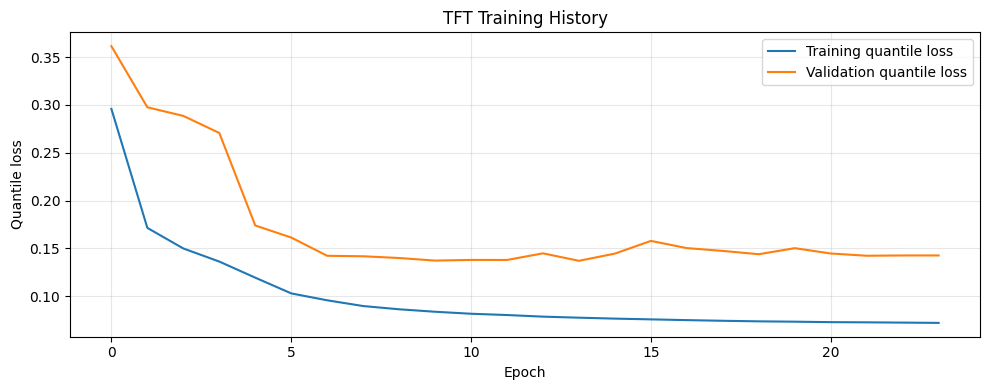


Best validation quantile loss: 0.1371 at epoch 14


In [70]:
# TFT TRAINING
# Validation is the time-ordered TAIL of the training windows. It is never the test set,
# and it is not a random shuffle - random splits on overlapping windows would let almost
# identical windows land on both sides and make early stopping meaningless.

n_val = max(1, int(n_windows * VALIDATION_FRACTION))
n_fit = n_windows - n_val

fit_inputs = {'encoder_inputs': X_enc[:n_fit], 'decoder_inputs': X_dec[:n_fit]}
val_inputs = {'encoder_inputs': X_enc[n_fit:], 'decoder_inputs': X_dec[n_fit:]}

print(f'Fitting on {n_fit} windows, validating on the final {n_val}')
print(f'On a GPU runtime this takes a few minutes; on CPU it will be considerably slower.\n')

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-5, verbose=1),
]

tft_history = tft_model.fit(
    fit_inputs, Y_tft[:n_fit],
    validation_data=(val_inputs, Y_tft[n_fit:]),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, shuffle=True, verbose=2)

plt.figure(figsize=(10, 4))
plt.plot(tft_history.history['loss'], label='Training quantile loss')
plt.plot(tft_history.history['val_loss'], label='Validation quantile loss')
plt.xlabel('Epoch')
plt.ylabel('Quantile loss')
plt.title('TFT Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/tft_training.jpg', dpi=100)
plt.show()

_best = min(tft_history.history['val_loss'])
print(f"\nBest validation quantile loss: {_best:.4f} "
      f"at epoch {tft_history.history['val_loss'].index(_best) + 1}")

In [71]:
# TFT FORECAST AND MODEL COMPARISON
# One forward pass produces the entire horizon. The encoder is seeded with the last
# ENCODER_LENGTH days of TRAINING data; the decoder receives only the test period's
# calendar, which is knowable in advance.

encoder_seed = np.concatenate([
    train_scaled_tft[-ENCODER_LENGTH:].reshape(-1, 1),
    cal_train[-ENCODER_LENGTH:],
], axis=1)[None, ...].astype('float32')
decoder_future = cal_test[None, ...].astype('float32')

assert encoder_seed.shape == (1, ENCODER_LENGTH, n_past)
assert decoder_future.shape == (1, DECODER_LENGTH, n_known)

q_scaled = tft_model.predict(
    {'encoder_inputs': encoder_seed, 'decoder_inputs': decoder_future}, verbose=0)[0]
q_pred = tft_scaler.inverse_transform(q_scaled.reshape(-1, 1)).reshape(q_scaled.shape)

y_pred_tft = q_pred[:, MEDIAN_IDX]
tft_lower, tft_upper = q_pred[:, 0], q_pred[:, -1]
y_true_tft = y_test.values

# forecast_metrics is defined in the RNN section; redefined here so this section can be
# run on its own.
if 'forecast_metrics' not in globals():
    def forecast_metrics(actual, predicted):
        mse = mean_squared_error(actual, predicted)
        return {'MSE': mse, 'RMSE': np.sqrt(mse),
                'MAE': mean_absolute_error(actual, predicted),
                'MAPE': np.mean(np.abs((actual - predicted) / actual)) * 100}

tft_metrics = forecast_metrics(y_true_tft, y_pred_tft)
rmse_tft, mae_tft, mape_tft = tft_metrics['RMSE'], tft_metrics['MAE'], tft_metrics['MAPE']

coverage = np.mean((y_true_tft >= tft_lower) & (y_true_tft <= tft_upper)) * 100
nominal = (QUANTILES[-1] - QUANTILES[0]) * 100

print('TFT Model Metrics (direct multi-horizon):')
print(f"  Root Mean Squared Error (RMSE): {rmse_tft:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_tft:.2f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mape_tft:.2f}%")
print(f"\n  P{int(QUANTILES[0]*100)}-P{int(QUANTILES[-1]*100)} interval covers "
      f"{coverage:.1f}% of actuals (nominal {nominal:.0f}%)")
if coverage < nominal - 15:
    print('  Interval is too narrow - the model is overconfident.')
elif coverage > nominal + 15:
    print('  Interval is too wide - the model is underconfident.')

# --- shared-task comparison ---------------------------------------------------
rw_pred_tft = np.full(len(y_test), y_train.values[-1])
mean_pred_tft = np.full(len(y_test), y_train.values.mean())
rw_m = forecast_metrics(y_true_tft, rw_pred_tft)
mean_m = forecast_metrics(y_true_tft, mean_pred_tft)

rows = [('STL-ARIMA', rmse_stl, mae_stl, mape_stl)]
if 'rmse_rnn' in globals():
    rows.append(('RNN (univariate, recursive)', rmse_rnn, mae_rnn, mape_rnn))
rows.append(('TFT (direct multi-horizon)', rmse_tft, mae_tft, mape_tft))
rows.append(('Random walk (last train value)', rw_m['RMSE'], rw_m['MAE'], rw_m['MAPE']))
rows.append(('Training mean', mean_m['RMSE'], mean_m['MAE'], mean_m['MAPE']))

print(f"\nAll models forecasting the same {DECODER_LENGTH}-day horizon with no test access:")
print(f"  {'Model':<34s} {'RMSE':>9s} {'MAE':>9s} {'MAPE':>9s}")
print(f"  {'-' * 62}")
for name, r, m, p in rows:
    print(f'  {name:<34s} {r:9.2f} {m:9.2f} {p:8.2f}%')

best_naive = min(rw_m['RMSE'], mean_m['RMSE'])
print('\nVerdict:')
if rmse_tft < rmse_stl:
    print(f'  TFT beats STL-ARIMA by {((rmse_stl - rmse_tft) / rmse_stl) * 100:.1f}% on RMSE')
else:
    print(f'  STL-ARIMA beats the TFT by {((rmse_tft - rmse_stl) / rmse_stl) * 100:.1f}% on RMSE')
if rmse_tft < best_naive:
    print(f'  TFT beats the best naive baseline by '
          f'{((best_naive - rmse_tft) / best_naive) * 100:.1f}% on RMSE')
else:
    print(f'  TFT does NOT beat the best naive baseline ({rmse_tft:.2f} vs {best_naive:.2f}).')
    print(f'  On this horizon, with this much data, the added capacity is not paying for itself.')

TFT Model Metrics (direct multi-horizon):
  Root Mean Squared Error (RMSE): 544.33
  Mean Absolute Error (MAE): 413.06
  Mean Absolute Percentage Error (MAPE): 122.69%

  P10-P90 interval covers 50.0% of actuals (nominal 80%)
  Interval is too narrow - the model is overconfident.

All models forecasting the same 502-day horizon with no test access:
  Model                                   RMSE       MAE      MAPE
  --------------------------------------------------------------
  STL-ARIMA                             904.95    742.77   225.16%
  RNN (univariate, recursive)           983.91    848.28   238.92%
  TFT (direct multi-horizon)            544.33    413.06   122.69%
  Random walk (last train value)        587.15    500.38   116.88%
  Training mean                         632.58    545.30   104.11%

Verdict:
  TFT beats STL-ARIMA by 39.8% on RMSE
  TFT beats the best naive baseline by 7.3% on RMSE


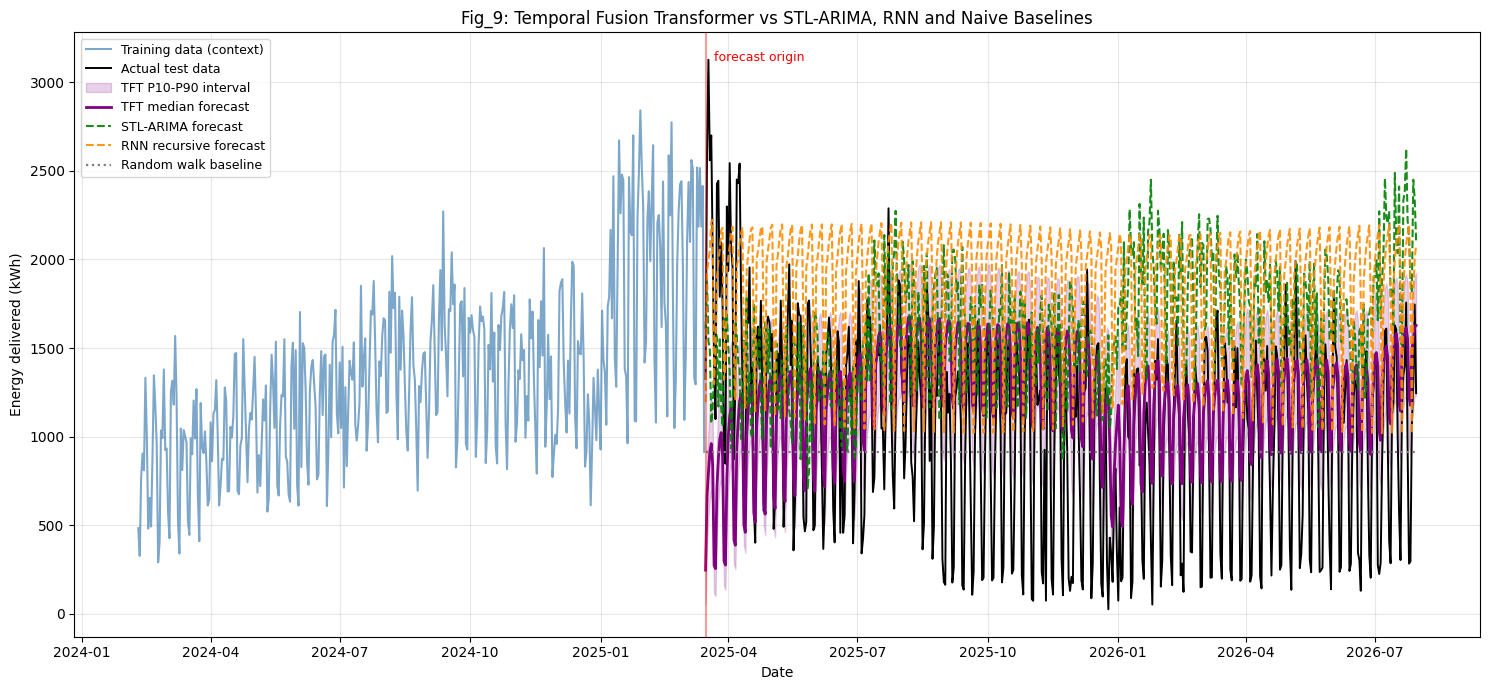

In [72]:
# TFT VISUALIZATION
plt.figure(figsize=(15, 7))

_ctx = min(len(y_train), 400)
plt.plot(y_train.index[-_ctx:], y_train.values[-_ctx:],
         label='Training data (context)', color='steelblue', alpha=0.7)
plt.plot(y_test.index, y_true_tft, label='Actual test data', color='black', linewidth=1.4)

plt.fill_between(y_test.index, tft_lower, tft_upper, color='purple', alpha=0.18,
                 label=f'TFT P{int(QUANTILES[0]*100)}-P{int(QUANTILES[-1]*100)} interval')
plt.plot(y_test.index, y_pred_tft, label='TFT median forecast',
         color='purple', linewidth=2)
plt.plot(y_test.index, forecast30, label='STL-ARIMA forecast',
         color='green', linestyle='--', alpha=0.9)
if 'y_pred_rnn' in globals():
    plt.plot(y_test.index, y_pred_rnn, label='RNN recursive forecast',
             color='darkorange', linestyle='--', alpha=0.9)
plt.plot(y_test.index, rw_pred_tft, label='Random walk baseline',
         color='grey', linestyle=':', linewidth=1.6)

plt.axvline(y_test.index[0], color='red', linestyle='-', alpha=0.4)
plt.annotate('forecast origin', xy=(y_test.index[0], plt.ylim()[1] * 0.95),
             xytext=(6, 0), textcoords='offset points', color='red', fontsize=9)

plt.title('Fig_9: Temporal Fusion Transformer vs STL-ARIMA, RNN and Naive Baselines')
plt.xlabel('Date')
plt.ylabel('Energy delivered (kWh)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/tft_forecast.jpg', dpi=100)
plt.show()

In [ ]:
# TFT INTERPRETABILITY - variable selection and attention
# This is the part of TFT that has value here regardless of the accuracy ranking: the
# model reports which inputs it used and which time positions it attended to.

_, attn_w, enc_w, dec_w = tft_inspect.predict(
    {'encoder_inputs': encoder_seed, 'decoder_inputs': decoder_future}, verbose=0)

enc_importance = enc_w[0].mean(axis=0)
dec_importance = dec_w[0].mean(axis=0)

print('Encoder variable selection (mean weight over the look-back window):')
for name, w in sorted(zip(PAST_FEATURE_NAMES, enc_importance), key=lambda t: -t[1]):
    print(f'  {name:<20s} {w:6.3f}  {"#" * int(round(w * 50))}')
print('\nDecoder variable selection (mean weight over the forecast horizon):')
for name, w in sorted(zip(KNOWN_FEATURE_NAMES, dec_importance), key=lambda t: -t[1]):
    print(f'  {name:<20s} {w:6.3f}  {"#" * int(round(w * 50))}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = np.argsort(enc_importance)
axes[0].barh([PAST_FEATURE_NAMES[i] for i in order], enc_importance[order], color='teal')
axes[0].set_title('Encoder variable importance')
axes[0].set_xlabel('Mean selection weight')
axes[0].grid(True, axis='x', alpha=0.3)

mean_attn = attn_w[0].mean(axis=0)
axes[1].plot(np.arange(len(mean_attn)), mean_attn, color='purple')
axes[1].axvline(ENCODER_LENGTH, color='red', linestyle='--', alpha=0.6)
axes[1].annotate('forecast origin', xy=(ENCODER_LENGTH, max(mean_attn) * 0.9),
                 xytext=(6, 0), textcoords='offset points', color='red', fontsize=9)
axes[1].set_title('Mean attention over input positions')
axes[1].set_xlabel('Position (0 = oldest encoder day)')
axes[1].set_ylabel('Mean attention weight')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fig_10: TFT Interpretability Outputs')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/tft_interpretability.jpg', dpi=100)
plt.show()

_enc_share = enc_importance[PAST_FEATURE_NAMES.index('energy_observed')]
_top_enc = PAST_FEATURE_NAMES[int(np.argmax(enc_importance))]
_top_dec = KNOWN_FEATURE_NAMES[int(np.argmax(dec_importance))]
print(f'\nReading these outputs:')
print(f'  The observed energy channel carries {_enc_share:.1%} of the encoder selection')
print(f'  weight; the most heavily weighted encoder input is "{_top_enc}".')
if _top_enc == 'energy_observed':
    print(f'  The model anchors its level on recent observed demand rather than on the calendar.')
else:
    print(f'  The model leans on the calendar rather than on recent levels, which on a')
    print(f'  plateaued series is a reasonable thing for it to do.')
print(f'  Over the horizon the dominant known-future input is "{_top_dec}" '
      f'({dec_importance.max():.1%}).')
_attn_enc = mean_attn[:ENCODER_LENGTH].sum()
print(f'  {_attn_enc:.1%} of attention mass falls on the encoder (history) rather than')
print(f'  on earlier decoder positions.')

## TFT Section Conclusions

*Written against the T4 run recorded in the cells above: 579 training windows, 142,126
parameters, early stopping at epoch 24 restoring epoch 14.*

### Result

| Model | RMSE | MAE | MAPE | R² vs test mean |
|---|---|---|---|---|
| STL-ARIMA | 904.95 | 742.77 | 225.16% | −1.499 |
| RNN (univariate, recursive) | 983.91 | 848.28 | 238.92% | −1.954 |
| **TFT (direct multi-horizon)** | **544.33** | **413.06** | 122.69% | **+0.096** |
| Random walk (last train value) | 587.15 | 500.38 | 116.88% | −0.052 |
| Training mean | 632.58 | 545.30 | 104.11% | −0.221 |

The last column is the one that settles the question. A forecast that somehow *knew* the
test-period mean in advance (1,043.7 kWh/day) and predicted that constant every day would
score RMSE 572.47. **TFT is the only model of the five that beats that oracle constant**,
and the only one with positive out-of-sample R²: it accounts for roughly 9.6% of test-period
variance. Every other model here — including both naive baselines — is worse than a flat
line drawn at the right height.

This reverses the expectation stated at the top of the section. Given ~580 heavily
overlapping windows against a six-figure parameter count, the honest prediction was that
TFT would overfit and lose to the random walk like everything else. It did not, and the
expectation is left in place above rather than quietly edited, because the prediction being
wrong is itself part of the result.

### Why it won

The test period is a hard one: it runs 2025-03-16 to 2026-07-30, averages 1,043.7 kWh/day
against a training mean of 774.5, and turns over inside the window — 1,177.7 kWh/day across
the first half, 909.6 across the second. That shape punishes both incumbents in the way each
was structurally exposed to:

* **STL-ARIMA** carries an explicit linear `trend='t'` term fitted on data that grew through
  2024. It projects that growth straight through a period that rose and then fell, and
  overshoots badly — RMSE 904.95, worse than doing nothing at all.
* **The RNN** forecasts recursively, so 502 steps of its own error compound. It ends up the
  worst of the five at 983.91.

TFT is exposed to neither. It emits all 502 days in one pass, so nothing compounds, and it
has no trend parameter to extrapolate. The `time_idx` feature was deliberately withheld for
exactly this reason, and the outcome supports that choice.

### What the model actually learned

The variable-selection and attention weights show a coherent strategy:

* **Encoder** — `energy_observed` is the single most heavily weighted input at 34.4%. The
  model sets its level from recent observed demand.
* **Decoder** — `month_sin` dominates at 62.3% of selection weight. The forward view is
  essentially an annual seasonal shape.
* **Attention** — only 33.7% of mass falls on encoder history; two-thirds lands on earlier
  decoder positions, i.e. the model propagates its own seasonal trajectory forward.

Read together: anchor the level on recent observations, then modulate it with an annual
cycle. That is a sensible thing to do on this series, and it also bounds how well the model
can possibly do — nothing in its inputs anticipates the mid-2025 turn, so it cannot forecast
the turn, only avoid being destroyed by it.

### Three caveats that limit what can be claimed

1. **The prediction intervals are not usable.** The P10–P90 band covers 50.0% of actuals
   against a nominal 80%. The model is badly overconfident and these bands should not be
   quoted to stakeholders without recalibration.

2. **The win is on absolute error only.** MAPE of 122.69% is *worse* than both naive
   baselines. 46 test days fall below 200 kWh and 110 below 400 kWh; on low-demand days a
   percentage error explodes regardless of how small the absolute miss is. If a decision
   depends on relative accuracy on quiet days, TFT is not the better model.

3. **This is one seed, one split, and a 7.3% RMSE margin.** Training loss of 0.0738 against
   validation 0.1371 at the best epoch confirms the model is overfitting, and early stopping
   is what kept it useful. A margin this size from a single run is suggestive, not
   established.

### Recommended next steps, in priority order

1. **Repeat across seeds and a rolling origin** before this result is relied on. Several
   seeds and several forecast origins would turn a single number into a distribution and
   show whether the 7.3% margin is real.
2. **Forecast per site rather than the county aggregate.** With 22 sites as separate
   entities the training windows multiply by roughly 22 and the static covariate path does
   the job it was designed for. This is the single highest-value change available.
3. **Shorten the horizon.** A 502-day forecast on 1,170 training days is an extreme ask;
   30- and 90-day horizons would give a far more useful read on all three models.
4. **Recalibrate the quantiles** — conformal prediction on a held-out slice would fix the
   coverage gap without retraining.
5. **Keep reporting every model against the naive baselines.** That practice is what caught
   the leakage in the RNN section and what makes this section's result meaningful; a model
   that cannot beat a constant should be visibly flagged as such.

### Effect on the notebook's earlier conclusions

The Conclusions and Future Work section above predates the extended data and this
comparison. Two of its claims no longer hold: that added model complexity did not improve
accuracy (TFT improves RMSE by 39.8% over STL-ARIMA), and that recurrent networks are the
natural next step (the LSTM is the worst model tested here). The README carries the same
framing and should be revisited alongside it.